E-Commerce Sales Analysis

## Phase 2: Exploratory Data Analysis with Pandas

This notebook is the full exploratory analysis of the fictional Pakistani
e-commerce dataset created in Phase 1.

**What this phase does NOT do:** it does not modify the original CSV files,
it does not run any SQL, and it does not build a dashboard. It reads the
data, checks it, understands it, and answers business questions with
calculated numbers only.

The analysis follows a deliberate order:

1. Understand the raw tables
2. Trust the data (quality checks)
3. Explore one table at a time
4. Combine the tables to answer business questions
5. Report metrics and findings

Every number in this notebook is calculated from the CSV files. Nothing is
hard-coded or assumed.

In [1]:
# ============================================================
# SECTION 2: IMPORT LIBRARIES
# ============================================================
# Only the three libraries agreed for this project are used:
# pandas for data handling, numpy for maths, matplotlib for charts.

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Make tables and charts easier to read
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

plt.style.use("bmh")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# A single colour palette is reused so every chart looks like part of one report
PALETTE = ["#2E6E9E", "#E07A3F", "#4C9A6A", "#B5485D",
           "#7A6FA8", "#C9A227", "#5B8DB8", "#8C7B5A"]

In [2]:
# ============================================================
# PATHS AND SMALL HELPERS
# ============================================================
# The notebook can be opened either from the project folder or from inside
# the notebooks folder. These two functions make the code work in both cases
# by searching upwards for the folder that contains the "data" directory.

def find_project_root():
    """Walk up from the current folder until we find the project root."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find the project root. Open this notebook from inside the "
        "E-Commerce-Sales-Analysis project folder."
    )


ROOT = find_project_root()
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "visualizations"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Every chart is saved here and also displayed in the notebook
CHART_NAMES = []


def save_fig(fig, name):
    """Save a figure to visualizations/ and show it in the notebook."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    CHART_NAMES.append(f"{name}.png")
    plt.show()


def thousands(value, _position):
    """Format an axis as 1,234,567 instead of 1234567."""
    return f"{value:,.0f}"


def money_axis(ax, axis="y"):
    """Apply thousands separators to a chart axis."""
    formatter = mtick.FuncFormatter(thousands)
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


print(f"Project root : {ROOT}")
print(f"Data folder  : {DATA_DIR}")
print(f"Charts saved : {FIG_DIR}")

Project root : C:\Users\HP\Documents\Default Project\E-Commerce-Sales-Analysis
Data folder  : C:\Users\HP\Documents\Default Project\E-Commerce-Sales-Analysis\data
Charts saved : C:\Users\HP\Documents\Default Project\E-Commerce-Sales-Analysis\visualizations


## Section 3: Load the Data

The five CSV files are loaded into five DataFrames. Nothing is written back,
so the original files on disk are never touched.

In [3]:
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")

TABLES = {
    "customers": customers,
    "products": products,
    "orders": orders,
    "orders_items": order_items,
    "payments": payments,
}

print("Loaded 5 tables\n")
print(f"{'Table':<14}{'Rows':>9}{'Columns':>10}   Description")
print("-" * 78)
descriptions = {
    "customers": "who the customer is",
    "products": "what is sold and at what price/cost",
    "orders": "order header: who, when, status, city",
    "orders_items": "the product lines inside each order",
    "payments": "how each order was paid",
}
for name, frame in TABLES.items():
    print(f"{name:<14}{len(frame):>9,}{len(frame.columns):>10}   {descriptions[name]}")

Loaded 5 tables

Table              Rows   Columns   Description
------------------------------------------------------------------------------
customers         1,500         7   who the customer is
products            300         8   what is sold and at what price/cost
orders           12,000         5   order header: who, when, status, city
orders_items     30,006         6   the product lines inside each order
payments         12,000         5   how each order was paid


## Section 4: Data Overview

Before analysing anything, look at the raw structure of each table:
its shape, its column names, and what type each column is stored as.

`dtypes` matters more than it looks. If `age` were stored as `object`
(text) instead of `int64`, every average we calculate later would fail or
silently give a wrong answer.

In [4]:
for name, frame in TABLES.items():
    print("=" * 78)
    print(f"{name.upper()}   shape = {frame.shape}")
    print("=" * 78)
    print(frame.dtypes.to_string())
    print()

CUSTOMERS   shape = (1500, 7)
customer_id      str
name             str
email            str
gender           str
age            int64
city             str
signup_date      str

PRODUCTS   shape = (300, 8)
product_id            str
product_name          str
category              str
subcategory           str
brand                 str
price             float64
cost              float64
stock_quantity      int64

ORDERS   shape = (12000, 5)
order_id         str
customer_id      str
order_date       str
status           str
shipping_city    str

ORDERS_ITEMS   shape = (30006, 6)
order_item_id           str
order_id                str
product_id              str
quantity              int64
unit_price          float64
discount_percent      int64

PAYMENTS   shape = (12000, 5)
payment_id        str
order_id          str
payment_method    str
payment_status    str
payment_date      str



In [5]:
# A quick look at the first few rows of each table
for name, frame in TABLES.items():
    print(f"--- {name} (first 3 rows) ---")
    print(frame.head(3).to_string(index=False))
    print()

--- customers (first 3 rows) ---
customer_id          name                                 email gender  age      city signup_date
 CUST-00001  Asad Hussain    asad.hussain.cust00001@outlook.com   Male   46    Lahore  2024-01-23
 CUST-00002 Rizwan Sattar   rizwan.sattar.cust00002@hotmail.com   Male   27 Islamabad  2024-11-30
 CUST-00003  Rania Shafiq rania.shafiq.cust00003@protonmail.com Female   45  Sargodha  2024-03-22

--- products (first 3 rows) ---
product_id              product_name    category subcategory   brand     price      cost  stock_quantity
 PROD-0001             Bose Soundbar Electronics       Audio    Bose 54,000.00 28,100.00             193
 PROD-0002        Sony Party Speaker Electronics       Audio    Sony 34,300.00 21,100.00              12
 PROD-0003 Samsung Bluetooth Speaker Electronics       Audio Samsung 10,900.00  7,900.00              35

--- orders (first 3 rows) ---
  order_id customer_id order_date    status shipping_city
ORD-000001  CUST-00340 2024-10-01

### 4.1 How the tables relate to each other

The dataset is normalised, so the tables are linked by key columns rather
than repeated across files:

```
customers.customer_id  <--->  orders.customer_id
orders.order_id        <--->  order_items.order_id
products.product_id    <--->  order_items.product_id
orders.order_id        <--->  payments.order_id
```

`orders` is the parent table. `order_items` and `payments` are children of
it, which means one order produces many order items but only one payment.
This structure is what makes the joins in Section 11 interesting, and it is
also where join mistakes are most likely.

In [6]:
print("Key columns and how many distinct values each holds:")
print("-" * 78)
print(f"customers.customer_id : {customers['customer_id'].nunique():>6,} distinct")
print(f"products.product_id   : {products['product_id'].nunique():>6,} distinct")
print(f"orders.order_id       : {orders['order_id'].nunique():>6,} distinct")
print(f"order_items.order_id  : {order_items['order_id'].nunique():>6,} distinct")
print(f"payments.order_id     : {payments['order_id'].nunique():>6,} distinct")
print()
print(f"-> {len(order_items):,} order item lines spread across "
      f"{order_items['order_id'].nunique():,} orders, so on average an order "
      f"contains {len(order_items) / order_items['order_id'].nunique():.2f} product lines.")
print(f"-> payments has exactly one row per order: "
      f"{len(payments) == len(orders)}")

Key columns and how many distinct values each holds:
------------------------------------------------------------------------------
customers.customer_id :  1,500 distinct
products.product_id   :    300 distinct
orders.order_id       : 12,000 distinct
order_items.order_id  : 12,000 distinct
payments.order_id     : 12,000 distinct

-> 30,006 order item lines spread across 12,000 orders, so on average an order contains 2.50 product lines.
-> payments has exactly one row per order: True


## Section 5: Data Quality Checks

Phase 1 already validated the dataset with a separate script. These are
*analysis-level* checks: they are repeated here, inside the notebook, so
that anyone reading the notebook can see for themselves that the numbers
below are safe to calculate.

The checks are grouped into:

* **Structure** - primary keys unique, foreign keys valid
* **Completeness** - missing values
* **Validity** - statuses, payment methods, categories, numeric ranges
* **Consistency** - dates that make sense, discounts and quantities allowed

The result of every check is collected into the `quality_report` DataFrame
so the whole report can be printed in one table at the end.

In [7]:
quality_report = []


def qcheck(name, passed, detail=""):
    """Record one data quality check for the final report."""
    quality_report.append({
        "Check": name,
        "Result": "PASS" if passed else "FAIL",
        "Detail": detail,
    })


# ---- Structure: primary keys must be unique -------------------------------
qcheck("customers.customer_id is unique",
       customers["customer_id"].is_unique,
       f"{customers['customer_id'].duplicated().sum()} duplicates")

qcheck("products.product_id is unique",
       products["product_id"].is_unique,
       f"{products['product_id'].duplicated().sum()} duplicates")

qcheck("orders.order_id is unique",
       orders["order_id"].is_unique,
       f"{orders['order_id'].duplicated().sum()} duplicates")

qcheck("order_items.order_item_id is unique",
       order_items["order_item_id"].is_unique,
       f"{order_items['order_item_id'].duplicated().sum()} duplicates")

qcheck("payments.payment_id is unique",
       payments["payment_id"].is_unique,
       f"{payments['payment_id'].duplicated().sum()} duplicates")

qcheck("customer email is unique",
       customers["email"].is_unique,
       f"{customers['email'].duplicated().sum()} duplicates")

# ---- Structure: foreign keys must resolve --------------------------------
orphan_orders = (~orders["customer_id"].isin(customers["customer_id"])).sum()
orphan_items = (~order_items["order_id"].isin(orders["order_id"])).sum()
orphan_products = (~order_items["product_id"].isin(products["product_id"])).sum()
orphan_payments = (~payments["order_id"].isin(orders["order_id"])).sum()

qcheck("orders.customer_id exists in customers", orphan_orders == 0,
       f"{orphan_orders} orphan rows")
qcheck("order_items.order_id exists in orders", orphan_items == 0,
       f"{orphan_items} orphan rows")
qcheck("order_items.product_id exists in products", orphan_products == 0,
       f"{orphan_products} orphan rows")
qcheck("payments.order_id exists in orders", orphan_payments == 0,
       f"{orphan_payments} orphan rows")

# ---- Structure: no duplicate product inside one order --------------------
repeated_product = order_items.duplicated(subset=["order_id", "product_id"]).sum()
qcheck("no duplicate product within an order", repeated_product == 0,
       f"{repeated_product} duplicated order/product pairs")

# ---- Completeness: no missing values -------------------------------------
for name, frame in TABLES.items():
    total_missing = int(frame.isna().sum().sum())
    qcheck(f"{name} has no missing values", total_missing == 0,
           f"{total_missing} missing cells")

# ---- Validity: categorical columns ----------------------------------------
VALID_ORDER_STATUS = {"Completed", "Pending", "Cancelled", "Returned"}
VALID_PAYMENT_STATUS = {"Paid", "Pending", "Failed", "Refunded"}
VALID_PAYMENT_METHOD = {"Cash on Delivery", "Credit Card", "Debit Card",
                        "Bank Transfer", "JazzCash", "EasyPaisa"}
VALID_GENDER = {"Male", "Female"}

qcheck("orders.status uses only valid values",
       set(orders["status"]) <= VALID_ORDER_STATUS,
       str(sorted(set(orders["status"]))))

qcheck("payments.payment_status uses only valid values",
       set(payments["payment_status"]) <= VALID_PAYMENT_STATUS,
       str(sorted(set(payments["payment_status"]))))

qcheck("payments.payment_method uses only valid values",
       set(payments["payment_method"]) <= VALID_PAYMENT_METHOD,
       str(sorted(set(payments["payment_method"]))))

qcheck("customers.gender uses only valid values",
       set(customers["gender"]) <= VALID_GENDER,
       str(sorted(set(customers["gender"]))))

# ---- Validity: numeric columns --------------------------------------------
qcheck("customers.age is a positive integer",
       bool(customers["age"].between(0, 120).all()),
       f"range {customers['age'].min()}-{customers['age'].max()}")

qcheck("products.price is never negative",
       bool((products["price"] > 0).all()),
       f"min PKR {products['price'].min():,.0f}")

qcheck("products.cost is never negative",
       bool((products["cost"] > 0).all()),
       f"min PKR {products['cost'].min():,.0f}")

qcheck("products.cost is lower than products.price",
       bool((products["cost"] < products["price"]).all()),
       "every product has a positive margin")

qcheck("products.stock_quantity is never negative",
       bool((products["stock_quantity"] >= 0).all()),
       f"range {products['stock_quantity'].min()}-{products['stock_quantity'].max()}")

qcheck("order_items.quantity is at least 1",
       bool((order_items["quantity"] >= 1).all()),
       f"range {order_items['quantity'].min()}-{order_items['quantity'].max()}")

qcheck("order_items.unit_price is never negative",
       bool((order_items["unit_price"] > 0).all()),
       f"min PKR {order_items['unit_price'].min():,.2f}")

# ---- Consistency: transaction price vs catalogue price --------------------
# products.price is the CURRENT catalogue price. order_items.unit_price is the
# price actually charged on that line. They are allowed to differ - prices move
# over time - so this is reported as an observation, not as a failure.
price_compare = order_items[["product_id", "unit_price"]].merge(
    products[["product_id", "price"]], on="product_id", how="left"
)
price_differs = (price_compare["unit_price"] - price_compare["price"]).abs() > 0.005
qcheck("unit_price vs catalogue price difference is understood",
       True,
       f"{int(price_differs.sum()):,} of {len(price_compare):,} lines differ")

# ---- Consistency: discounts -----------------------------------------------
bad_discount = (~order_items["discount_percent"].between(0, 100)).sum()
qcheck("order_items.discount_percent is between 0 and 100", bad_discount == 0,
       f"values used: {sorted(int(value) for value in order_items['discount_percent'].unique())}")

qcheck("order_items.discount_percent is realistic (0-30)",
       bool((order_items["discount_percent"] <= 30).all()),
       f"{(order_items['discount_percent'] <= 30).mean():.1%} of lines are 0-30%")

# ---- Consistency: dates ---------------------------------------------------
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
payments["payment_date"] = pd.to_datetime(payments["payment_date"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")

qcheck("no unparsable dates", int(orders["order_date"].isna().sum()) == 0,
       f"orders {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")

first_order = orders.groupby("customer_id")["order_date"].min()
signup_of_customer = customers.set_index("customer_id")["signup_date"]
orders_before_signup = (
    orders["customer_id"].map(signup_of_customer) > orders["order_date"]
).sum()
qcheck("no order is placed before the customer signed up",
       orders_before_signup == 0,
       f"{orders_before_signup} violations")

payment_order_date = payments["order_id"].map(
    orders.set_index("order_id")["order_date"]
)
early_payments = (payments["payment_date"] < payment_order_date).sum()
qcheck("no payment is dated before its order", early_payments == 0,
       f"{early_payments} violations")

# ---- Completeness: every order has items and a payment --------------------
orders_without_items = (~orders["order_id"].isin(order_items["order_id"])).sum()
orders_without_payment = (~orders["order_id"].isin(payments["order_id"])).sum()
qcheck("every order has at least one order item", orders_without_items == 0,
       f"{orders_without_items} empty orders")
qcheck("every order has exactly one payment", orders_without_payment == 0
       and payments["order_id"].is_unique,
       f"{orders_without_payment} orders without payment")

In [8]:
# Print the collected quality report
quality_report = pd.DataFrame(quality_report)
failed_checks = int((quality_report["Result"] == "FAIL").sum())

print("=" * 100)
print("DATA QUALITY REPORT")
print("=" * 100)
print(quality_report.to_string(index=False))
print("=" * 100)
print(f"Checks run : {len(quality_report)}")
print(f"Passed     : {len(quality_report) - failed_checks}")
print(f"Failed     : {failed_checks}")
print("=" * 100)

DATA QUALITY REPORT
                                                 Check Result                                                                                      Detail
                       customers.customer_id is unique   PASS                                                                                0 duplicates
                         products.product_id is unique   PASS                                                                                0 duplicates
                             orders.order_id is unique   PASS                                                                                0 duplicates
                   order_items.order_item_id is unique   PASS                                                                                0 duplicates
                         payments.payment_id is unique   PASS                                                                                0 duplicates
                              customer email is unique  

## Section 6: Customer Analysis

`customers.csv` holds one row per customer. This section answers:
how many customers there are, how old they are, where they live, when they
joined, and whether the file is clean.

In [9]:
print("customers shape :", customers.shape)
print("columns         :", list(customers.columns))
print()
print(customers.dtypes.to_string())
print()
print("Missing values per column:")
print(customers.isna().sum().to_string())
print()
print("Fully duplicated rows      :", int(customers.duplicated().sum()))
print("Duplicate customer_id      :", int(customers["customer_id"].duplicated().sum()))
print("Duplicate email addresses  :", int(customers["email"].duplicated().sum()))
print("Unique cities              :", customers["city"].nunique())
print("Signup date range          :", customers["signup_date"].min().date(),
      "to", customers["signup_date"].max().date())

customers shape : (1500, 7)
columns         : ['customer_id', 'name', 'email', 'gender', 'age', 'city', 'signup_date']

customer_id               str
name                      str
email                     str
gender                    str
age                     int64
city                      str
signup_date    datetime64[us]

Missing values per column:
customer_id    0
name           0
email          0
gender         0
age            0
city           0
signup_date    0

Fully duplicated rows      : 0
Duplicate customer_id      : 0
Duplicate email addresses  : 0
Unique cities              : 20
Signup date range          : 2022-10-08 to 2026-08-19


In [10]:
# Descriptive statistics for the numeric columns
age_stats = customers["age"].describe()
print("Age statistics")
print("-" * 60)
print(f"count : {age_stats['count']:,.0f}")
print(f"mean  : {age_stats['mean']:.1f}")
print(f"std   : {age_stats['std']:.1f}")
print(f"min   : {age_stats['min']:.0f}")
print(f"25%   : {age_stats['25%']:.0f}")
print(f"50%   : {age_stats['50%']:.0f}")
print(f"75%   : {age_stats['75%']:.0f}")
print(f"max   : {age_stats['max']:.0f}")
print()
print("The mean sits above the median, which means the age distribution has a "
      "longer tail of older customers rather than being symmetric.")

Age statistics
------------------------------------------------------------
count : 1,500
mean  : 33.5
std   : 9.4
min   : 18
25%   : 27
50%   : 33
75%   : 40
max   : 65

The mean sits above the median, which means the age distribution has a longer tail of older customers rather than being symmetric.


Customers by age band
------------------------------------------------------------
18-24       279    18.6%  ###########
25-34       535    35.7%  #####################
35-44       502    33.5%  ####################
45-54       149     9.9%  #####
55-64        34     2.3%  #
65+           1     0.1%  


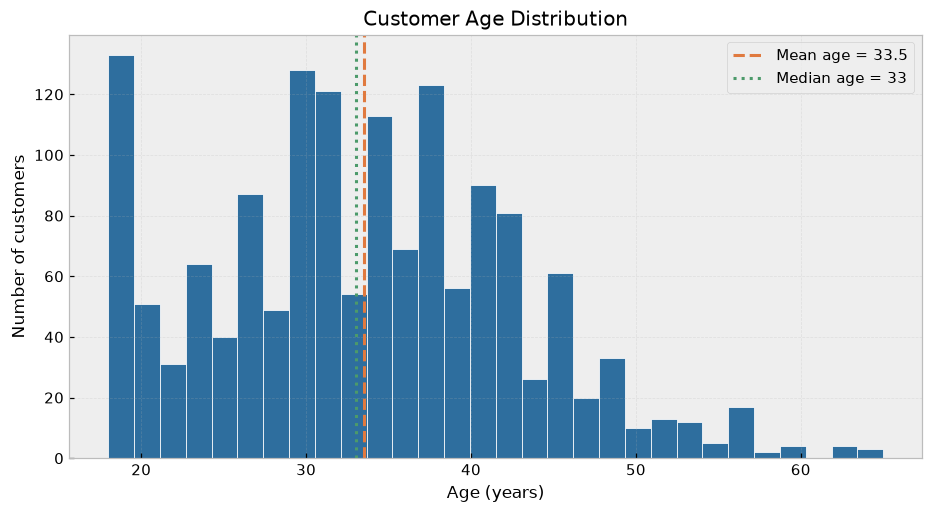

In [11]:
# Age distribution in readable bands
age_bands = pd.cut(
    customers["age"],
    bins=[17, 24, 34, 44, 54, 64, 75],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
)
age_band_counts = age_bands.value_counts().sort_index()

print("Customers by age band")
print("-" * 60)
for band, count in age_band_counts.items():
    share = count / len(customers)
    print(f"{band:<8}{count:>7,}{share:>9.1%}  {'#' * int(share * 60)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(customers["age"], bins=30, color=PALETTE[0], edgecolor="white")
ax.axvline(customers["age"].mean(), color=PALETTE[1], linestyle="--", linewidth=2,
           label=f"Mean age = {customers['age'].mean():.1f}")
ax.axvline(customers["age"].median(), color=PALETTE[2], linestyle=":", linewidth=2,
           label=f"Median age = {customers['age'].median():.0f}")
ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of customers")
ax.legend()
save_fig(fig, "01_customer_age_distribution")

Gender distribution
------------------------------------------------------------
Male          783    52.2%
Female        717    47.8%


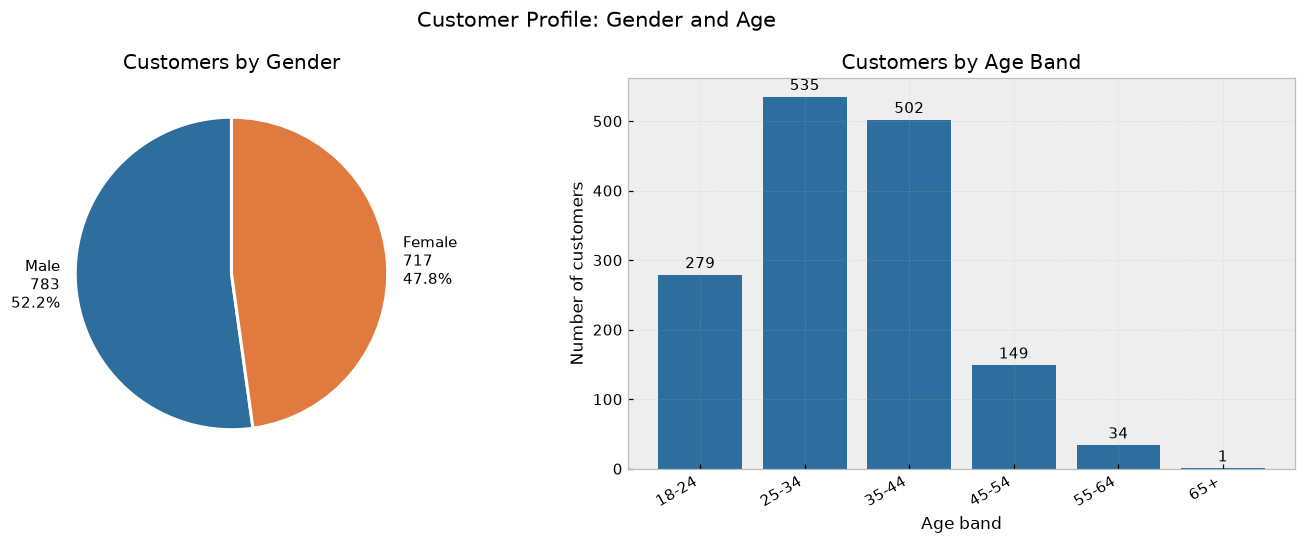

In [12]:
# Gender split
gender_counts = customers["gender"].value_counts()
print("Gender distribution")
print("-" * 60)
for gender, count in gender_counts.items():
    print(f"{gender:<10}{count:>7,}{count / len(customers):>9.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    gender_counts,
    labels=[f"{g}\n{c:,}\n{c / len(customers):.1%}" for g, c in gender_counts.items()],
    colors=PALETTE[:2],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Customers by Gender")

axes[1].bar(age_band_counts.index.astype(str), age_band_counts.values, color=PALETTE[0])
axes[1].set_title("Customers by Age Band")
axes[1].set_xlabel("Age band")
axes[1].set_ylabel("Number of customers")
axes[1].bar_label(axes[1].containers[0], padding=2, fmt="{:,.0f}")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

fig.suptitle("Customer Profile: Gender and Age", fontsize=14)
fig.tight_layout()
save_fig(fig, "02_customer_gender_and_age_band")

Customers spread across 20 cities
------------------------------------------------------------
          city  customers  share
       Karachi        297   0.20
        Lahore        292   0.19
     Islamabad        136   0.09
    Rawalpindi        121   0.08
    Faisalabad         98   0.07
      Peshawar         78   0.05
        Multan         62   0.04
    Gujranwala         59   0.04
        Quetta         49   0.03
     Hyderabad         45   0.03
    Bahawalpur         44   0.03
       Sialkot         42   0.03
      Sargodha         35   0.02
    Abbottabad         27   0.02
        Sukkur         24   0.02
Rahim Yar Khan         22   0.01
       Sahiwal         22   0.01
   Mirpur Khas         19   0.01
        Mardan         15   0.01
        Gwadar         13   0.01

The top 3 cities (Karachi, Lahore, Islamabad) hold 48.3% of all customers, so the customer base is strongly concentrated in the large metros rather than spread evenly.


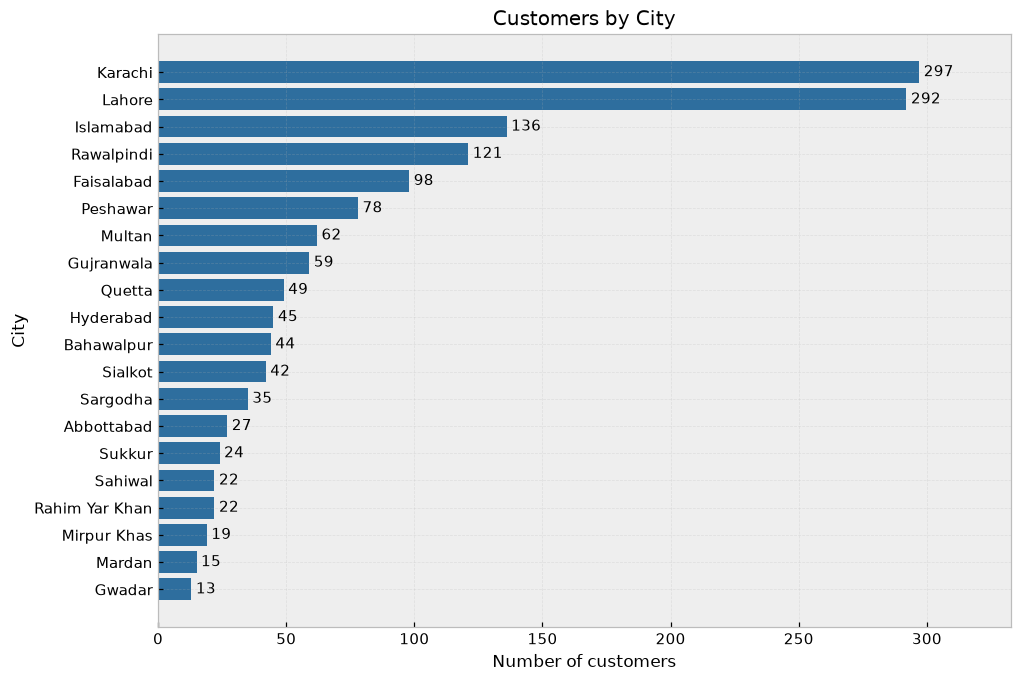

In [13]:
# Customers by city
city_counts = (customers["city"].value_counts()
               .rename_axis("city").reset_index(name="customers"))
city_counts["share"] = city_counts["customers"] / len(customers)
city_counts = city_counts.sort_values("customers", ascending=False)

print(f"Customers spread across {len(city_counts)} cities")
print("-" * 60)
print(city_counts.to_string(index=False))
print()
top3_share = city_counts["share"].head(3).sum()
print(f"The top 3 cities ({', '.join(city_counts['city'].head(3))}) hold "
      f"{top3_share:.1%} of all customers, so the customer base is strongly "
      f"concentrated in the large metros rather than spread evenly.")

fig, ax = plt.subplots(figsize=(10, 7))
plot_city = city_counts.sort_values("customers")
bars = ax.barh(plot_city["city"], plot_city["customers"], color=PALETTE[0])
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set_title("Customers by City")
ax.set_xlabel("Number of customers")
ax.set_ylabel("City")
ax.set_xlim(0, plot_city["customers"].max() * 1.12)
save_fig(fig, "03_customers_by_city")

New customers per signup year
------------------------------------------------------------
 year  customers
 2022         62
 2023        584
 2024        681
 2025        154
 2026         19

New customers per signup month (first 12 shown)
------------------------------------------------------------
  month  customers
2022-10          7
2022-11         24
2022-12         31
2023-01         37
2023-02         31
2023-03         49
2023-04         51
2023-05         39
2023-06         48
2023-07         48
2023-08         61
2023-09         64


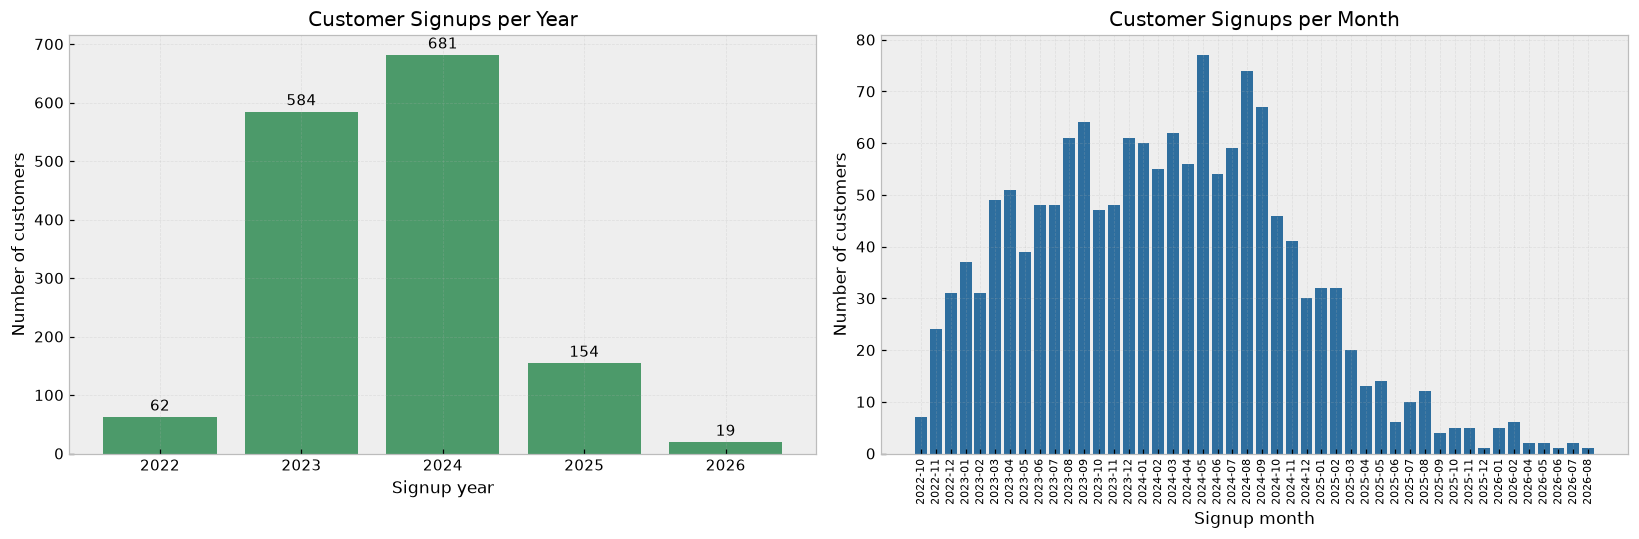

In [14]:
# Signup dates: range, by year, by month
signup_by_year = (customers["signup_date"].dt.year
                  .value_counts().sort_index().rename_axis("year").reset_index(name="customers"))
signup_by_month = (customers["signup_date"].dt.to_period("M")
                   .value_counts().sort_index().rename_axis("month").reset_index(name="customers"))

print("New customers per signup year")
print("-" * 60)
print(signup_by_year.to_string(index=False))
print()
print("New customers per signup month (first 12 shown)")
print("-" * 60)
print(signup_by_month.head(12).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(signup_by_year["year"].astype(str), signup_by_year["customers"], color=PALETTE[2])
axes[0].set_title("Customer Signups per Year")
axes[0].set_xlabel("Signup year")
axes[0].set_ylabel("Number of customers")
axes[0].bar_label(axes[0].containers[0], padding=2, fmt="{:,.0f}")

axes[1].bar(signup_by_month["month"].astype(str), signup_by_month["customers"],
            color=PALETTE[0])
axes[1].set_title("Customer Signups per Month")
axes[1].set_xlabel("Signup month")
axes[1].set_ylabel("Number of customers")
plt.setp(axes[1].get_xticklabels(), rotation=90, fontsize=7)
plt.setp(axes[0].get_xticklabels(), rotation=0)

fig.tight_layout()
save_fig(fig, "04_customer_signups_over_time")

## Section 7: Product Analysis

`products.csv` is the catalogue. The interesting part of this table is the
relationship between `price` and `cost`: the difference between them is the
gross profit the company makes on a single unit.

Two derived columns are created **in memory only**:

```
profit_per_unit = price - cost
margin_percent   = (price - cost) / price * 100
```

`margin_percent` is the more useful of the two for comparing products,
because a 5,000 PKR margin means something very different on a 500 PKR
grocery item than on a 300,000 PKR laptop.

In [15]:
print("products shape :", products.shape)
print("columns        :", list(products.columns))
print()
print(products.dtypes.to_string())
print()
print("Missing values per column:")
print(products.isna().sum().to_string())
print()
print("Fully duplicated rows :", int(products.duplicated().sum()))
print("Duplicate product_id  :", int(products["product_id"].duplicated().sum()))
print("Duplicate names       :", int(products["product_name"].duplicated().sum()))
print()
print(f"Categories    : {products['category'].nunique()}")
print(f"Subcategories : {products['subcategory'].nunique()}")
print(f"Brands        : {products['brand'].nunique()}")

products shape : (300, 8)
columns        : ['product_id', 'product_name', 'category', 'subcategory', 'brand', 'price', 'cost', 'stock_quantity']

product_id            str
product_name          str
category              str
subcategory           str
brand                 str
price             float64
cost              float64
stock_quantity      int64

Missing values per column:
product_id        0
product_name      0
category          0
subcategory       0
brand             0
price             0
cost              0
stock_quantity    0

Fully duplicated rows : 0
Duplicate product_id  : 0
Duplicate names       : 0

Categories    : 10
Subcategories : 39
Brands        : 137


In [16]:
# Derived profit values, kept in memory only - the CSV file is never changed
products["profit_per_unit"] = products["price"] - products["cost"]
products["margin_percent"] = (products["profit_per_unit"] / products["price"]) * 100

print("Price statistics (PKR)")
print("-" * 70)
print(products["price"].describe().to_string())
print()
print("Cost statistics (PKR)")
print("-" * 70)
print(products["cost"].describe().to_string())
print()
print("Stock statistics (units)")
print("-" * 70)
print(products["stock_quantity"].describe().to_string())
print()
print("Derived profit")
print("-" * 70)
print(f"profit_per_unit : min PKR {products['profit_per_unit'].min():,.0f}  "
      f"max PKR {products['profit_per_unit'].max():,.0f}  "
      f"mean PKR {products['profit_per_unit'].mean():,.0f}")
print(f"margin_percent   : min {products['margin_percent'].min():.1f}%  "
      f"max {products['margin_percent'].max():.1f}%  "
      f"mean {products['margin_percent'].mean():.1f}%")
print()
print(f"Stock value at cost   : PKR {(products['cost'] * products['stock_quantity']).sum():,.0f}")
print(f"Stock value at retail : PKR {(products['price'] * products['stock_quantity']).sum():,.0f}")
print(f"Products out of stock : {(products['stock_quantity'] == 0).sum()} "
      f"({(products['stock_quantity'] == 0).mean():.1%})")

Price statistics (PKR)
----------------------------------------------------------------------
count       300.00
mean     28,311.23
std      58,091.38
min         170.00
25%       1,500.00
50%       4,625.00
75%      17,075.00
max     369,500.00

Cost statistics (PKR)
----------------------------------------------------------------------
count       300.00
mean     18,560.00
std      37,391.82
min         130.00
25%       1,032.50
50%       2,925.00
75%      13,050.00
max     253,000.00

Stock statistics (units)
----------------------------------------------------------------------
count   300.00
mean    112.64
std     149.20
min       0.00
25%      12.00
50%      41.00
75%     151.25
max     599.00

Derived profit
----------------------------------------------------------------------
profit_per_unit : min PKR 40  max PKR 169,000  mean PKR 9,751
margin_percent   : min 11.1%  max 55.9%  mean 32.0%

Stock value at cost   : PKR 461,125,640
Stock value at retail : PKR 691,323,970
Products 

Products by category, with average price, cost and margin
--------------------------------------------------------------------------------------------------------------
                    products  avg_price  avg_cost  avg_margin_percent  total_stock
category                                                                          
Home Appliances           30 114,106.67 75,806.67               32.14         3419
Computers                 31  69,991.94 45,100.97               33.53         3080
Electronics               30  56,881.67 35,541.67               34.63         3686
Home & Kitchen            30  12,856.67  8,525.67               33.55         3097
Sports                    30  10,096.67  7,508.00               27.80         2963
Fashion                   31   6,488.71  4,519.68               32.49         3531
Mobile Accessories        30   4,161.67  2,810.33               33.86         2759
Beauty                    31   3,552.90  2,420.00               31.48         3254
B

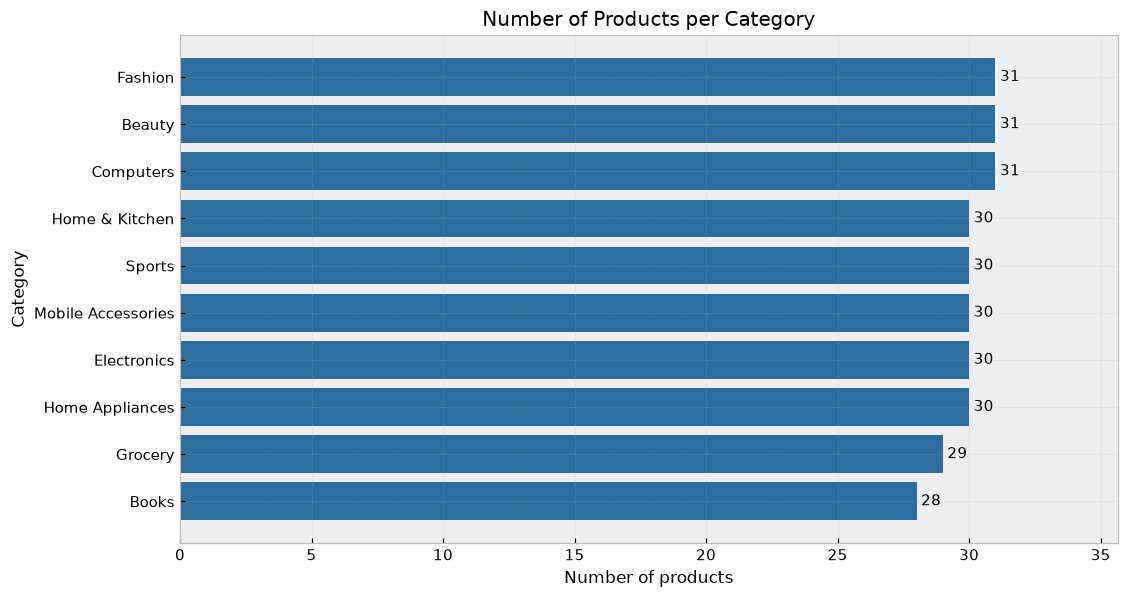

In [17]:
# Products per category and subcategory
products_by_category = (products.groupby("category")
                        .agg(products=("product_id", "count"),
                             avg_price=("price", "mean"),
                             avg_cost=("cost", "mean"),
                             avg_margin_percent=("margin_percent", "mean"),
                             total_stock=("stock_quantity", "sum"))
                        .sort_values("avg_price", ascending=False))

print("Products by category, with average price, cost and margin")
print("-" * 110)
print(products_by_category.to_string())
print()
print("Average products per subcategory :",
      f"{len(products) / products['subcategory'].nunique():.1f}")

fig, ax = plt.subplots(figsize=(11, 6))
plot_cat = products_by_category.sort_values("products")
bars = ax.barh(plot_cat.index, plot_cat["products"], color=PALETTE[0])
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set_title("Number of Products per Category")
ax.set_xlabel("Number of products")
ax.set_ylabel("Category")
ax.set_xlim(0, plot_cat["products"].max() * 1.15)
save_fig(fig, "05_products_by_category")

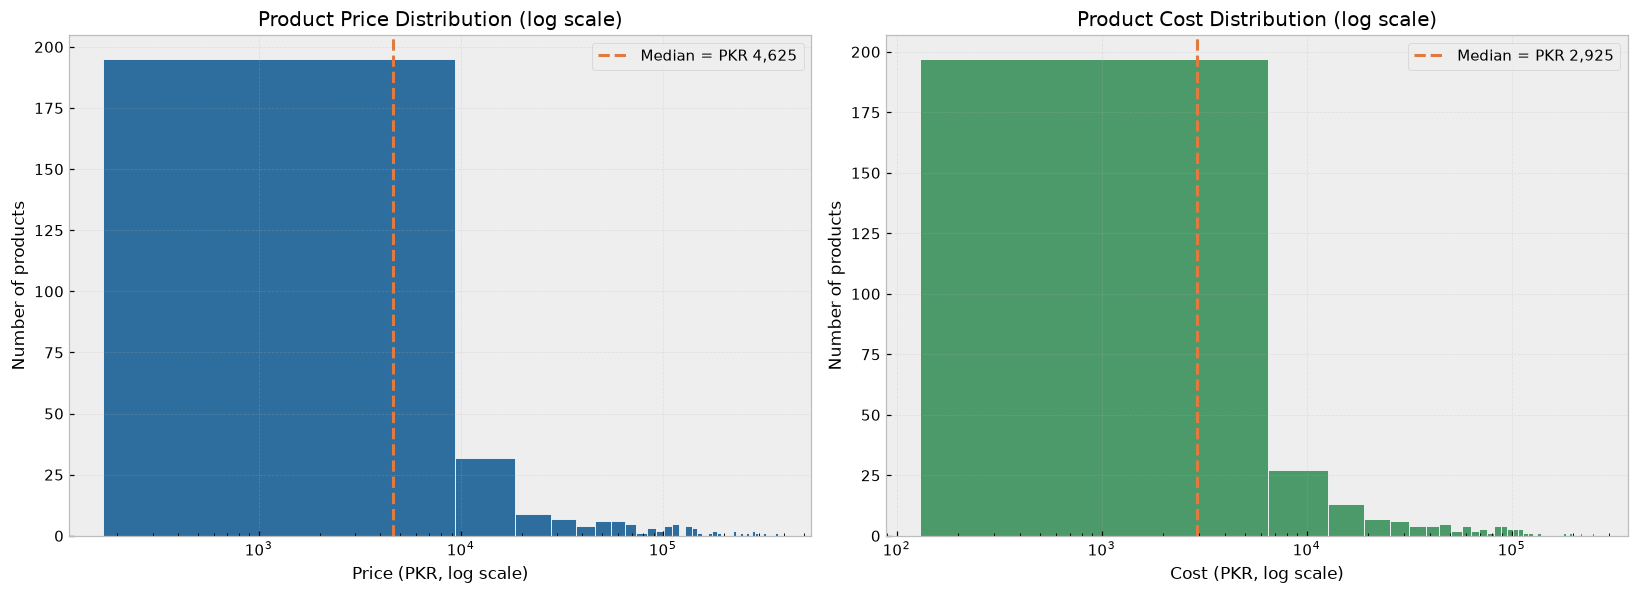

In [18]:
# Price and cost distributions.
# Prices range from a few hundred to several hundred thousand PKR, so a normal
# histogram puts almost every product into the first bar. A logarithmic x-axis
# spreads the values out and makes the shape readable.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].hist(products["price"], bins=40, color=PALETTE[0], edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Product Price Distribution (log scale)")
axes[0].set_xlabel("Price (PKR, log scale)")
axes[0].set_ylabel("Number of products")
axes[0].axvline(products["price"].median(), color=PALETTE[1], linestyle="--",
                linewidth=2, label=f"Median = PKR {products['price'].median():,.0f}")
axes[0].legend()

axes[1].hist(products["cost"], bins=40, color=PALETTE[2], edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Product Cost Distribution (log scale)")
axes[1].set_xlabel("Cost (PKR, log scale)")
axes[1].set_ylabel("Number of products")
axes[1].axvline(products["cost"].median(), color=PALETTE[1], linestyle="--",
                linewidth=2, label=f"Median = PKR {products['cost'].median():,.0f}")
axes[1].legend()

fig.tight_layout()
save_fig(fig, "06_price_and_cost_distribution")

Category economics, sorted by average margin
--------------------------------------------------------------------------------------------------------------
                    products  avg_price  avg_cost  avg_profit_per_unit  avg_margin_percent
category                                                                                  
Electronics               30  56,881.67 35,541.67            21,340.00               34.63
Mobile Accessories        30   4,161.67  2,810.33             1,351.33               33.86
Home & Kitchen            30  12,856.67  8,525.67             4,331.00               33.55
Computers                 31  69,991.94 45,100.97            24,890.97               33.53
Fashion                   31   6,488.71  4,519.68             1,969.03               32.49
Home Appliances           30 114,106.67 75,806.67            38,300.00               32.14
Beauty                    31   3,552.90  2,420.00             1,132.90               31.48
Books                    

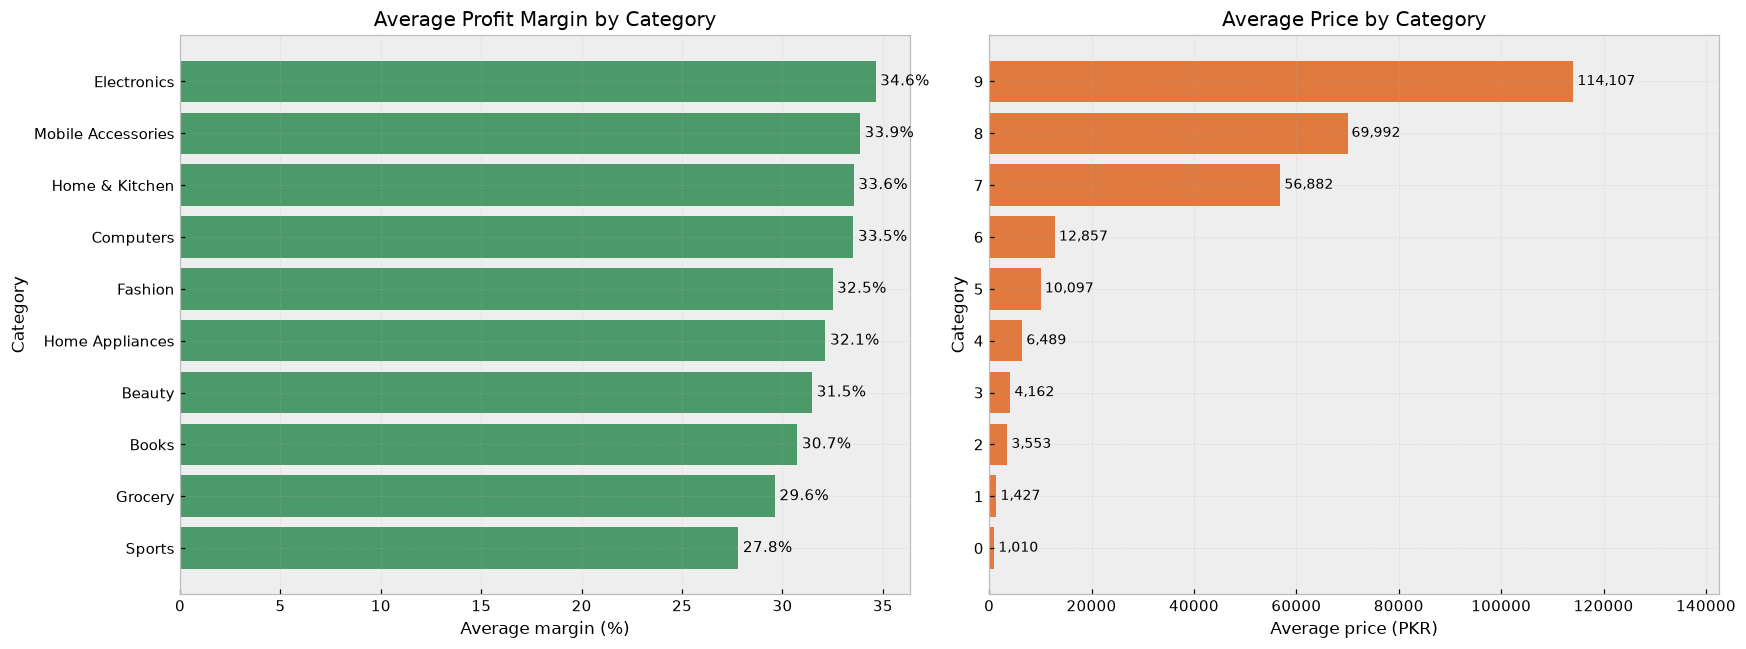

In [19]:
# Category-level pricing and margin
category_economics = (products.groupby("category")
                      .agg(products=("product_id", "count"),
                           avg_price=("price", "mean"),
                           avg_cost=("cost", "mean"),
                           avg_profit_per_unit=("profit_per_unit", "mean"),
                           avg_margin_percent=("margin_percent", "mean"))
                      .sort_values("avg_margin_percent", ascending=False))
print("Category economics, sorted by average margin")
print("-" * 110)
print(category_economics.to_string())
print()
print("Most expensive category :", category_economics["avg_price"].idxmax(),
      f"at PKR {category_economics['avg_price'].max():,.0f} average")
print("Cheapest category      :", category_economics["avg_price"].idxmin(),
      f"at PKR {category_economics['avg_price'].min():,.0f} average")
print("Highest margin category:", category_economics["avg_margin_percent"].idxmax(),
      f"at {category_economics['avg_margin_percent'].max():.1f}%")
print("Lowest margin category :", category_economics["avg_margin_percent"].idxmin(),
      f"at {category_economics['avg_margin_percent'].min():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

margin_plot = category_economics.sort_values("avg_margin_percent")
axes[0].barh(margin_plot.index, margin_plot["avg_margin_percent"], color=PALETTE[2])
axes[0].set_title("Average Profit Margin by Category")
axes[0].set_xlabel("Average margin (%)")
axes[0].set_ylabel("Category")
axes[0].bar_label(axes[0].containers[0], padding=3, fmt="%.1f%%")

price_plot = category_economics.sort_values("avg_price")
axes[1].barh(price_plot.index, price_plot["avg_price"], color=PALETTE[1])
axes[1].set_title("Average Price by Category")
axes[1].set_xlabel("Average price (PKR)")
axes[1].set_ylabel("Category")
money_axis(axes[1])
for position, value in enumerate(price_plot["avg_price"]):
    axes[1].text(value, position, f" {value:,.0f}", va="center", fontsize=9)
axes[1].set_xlim(0, price_plot["avg_price"].max() * 1.25)

fig.tight_layout()
save_fig(fig, "07_category_price_and_margin")

## Section 8: Order Analysis

`orders.csv` is the parent table. One row = one order placed by one customer
on one date, with a status and a delivery city.

Two things are examined carefully here:

1. **Status** - not all orders end the same way. Cancelled and returned
orders still exist in the data but should not be counted as successful
sales. This distinction is carried through every metric in Section 12.
2. **Time** - orders are grouped into months so the trend can be charted.

In [20]:
print("orders shape :", orders.shape)
print("columns      :", list(orders.columns))
print()
print(orders.dtypes.to_string())
print()
print("Missing values per column:")
print(orders.isna().sum().to_string())
print()
print("Fully duplicated rows :", int(orders.duplicated().sum()))
print("Duplicate order_id    :", int(orders["order_id"].duplicated().sum()))
print()
print(f"Date range : {orders['order_date'].min().date()} to "
      f"{orders['order_date'].max().date()} "
      f"({(orders['order_date'].max() - orders['order_date'].min()).days} days)")
print(f"Shipping cities used : {orders['shipping_city'].nunique()}")

orders shape : (12000, 5)
columns      : ['order_id', 'customer_id', 'order_date', 'status', 'shipping_city']

order_id                    str
customer_id                 str
order_date       datetime64[us]
status                      str
shipping_city               str

Missing values per column:
order_id         0
customer_id      0
order_date       0
status           0
shipping_city    0

Fully duplicated rows : 0
Duplicate order_id    : 0

Date range : 2024-10-01 to 2026-09-26 (725 days)
Shipping cities used : 20


Order status distribution
------------------------------------------------------------
           share  orders
status                  
Completed   0.76    9076
Pending     0.10    1220
Returned    0.08     930
Cancelled   0.06     774

Completed :  75.6%
Pending   :  10.2%
Returned  :   7.8%
Cancelled :   6.5%

Completed orders are the clear majority, while cancelled and returned orders together are only 14.2%. Pending orders are higher than expected because they are concentrated in the most recent weeks, where an order has not had time to complete yet.


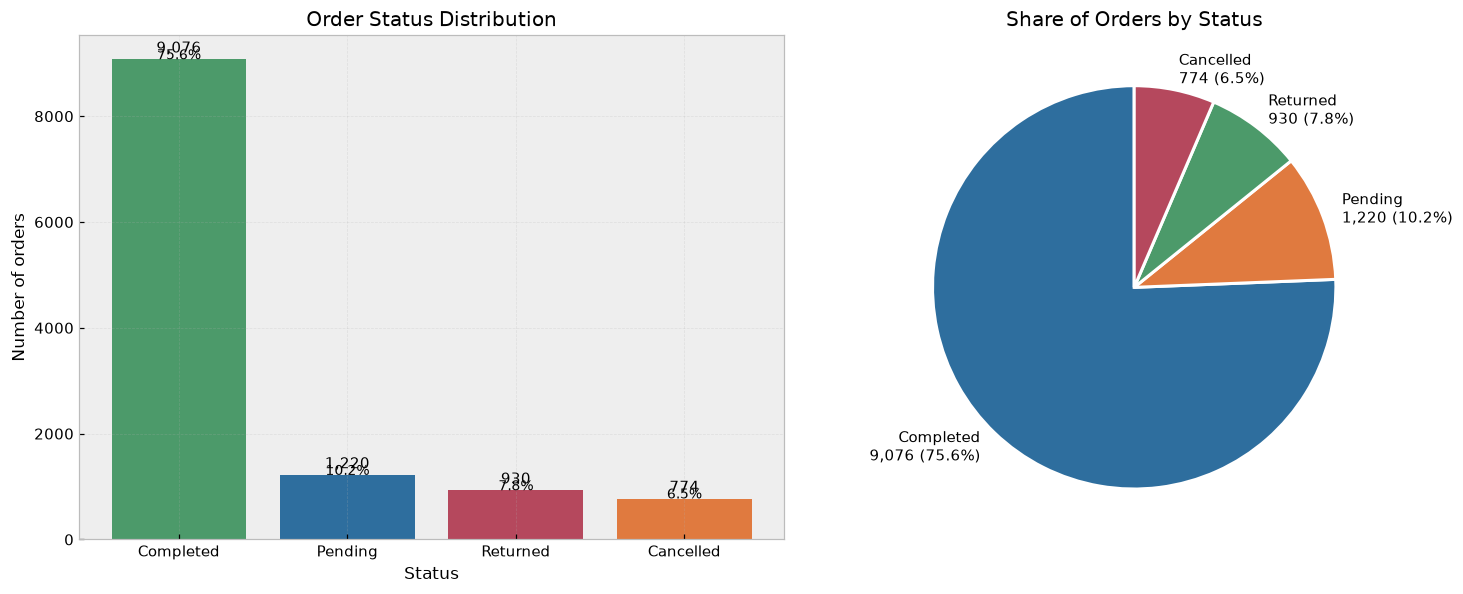

In [21]:
status_counts = orders["status"].value_counts()
status_summary = (orders["status"].value_counts(normalize=True)
                  .rename("share").to_frame()
                  .assign(orders=status_counts))
print("Order status distribution")
print("-" * 60)
print(status_summary.to_string())

completed_share = (orders["status"] == "Completed").mean()
cancelled_share = (orders["status"] == "Cancelled").mean()
returned_share = (orders["status"] == "Returned").mean()
pending_share = (orders["status"] == "Pending").mean()
print()
print(f"Completed : {completed_share:6.1%}")
print(f"Pending   : {pending_share:6.1%}")
print(f"Returned  : {returned_share:6.1%}")
print(f"Cancelled : {cancelled_share:6.1%}")
print()
print(f"Completed orders are the clear majority, while cancelled and returned "
      f"orders together are only {cancelled_share + returned_share:.1%}. "
      f"Pending orders are higher than expected because they are concentrated "
      f"in the most recent weeks, where an order has not had time to complete yet.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
status_plot = status_counts.sort_values(ascending=False)

axes[0].bar(status_plot.index, status_plot.values,
            color=[PALETTE[2], PALETTE[0], PALETTE[3], PALETTE[1]])
axes[0].set_title("Order Status Distribution")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Number of orders")
axes[0].bar_label(axes[0].containers[0], padding=2, fmt="{:,.0f}")
for position, (label, value) in enumerate(status_plot.items()):
    axes[0].text(position, value, f"\n{value / len(orders):.1%}", ha="center", fontsize=9)

axes[1].pie(
    status_plot.values,
    labels=[f"{label}\n{value:,} ({value / len(orders):.1%})"
            for label, value in status_plot.items()],
    colors=PALETTE[:len(status_plot)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Share of Orders by Status")

fig.tight_layout()
save_fig(fig, "08_order_status_distribution")

Orders per year
------------------------------------------------------------
 order_year  orders
       2024    1199
       2025    5731
       2026    5070

Orders per month
------------------------------------------------------------
order_month  orders  completed_orders
    2024-10     378               290
    2024-11     399               309
    2024-12     422               333
    2025-01     410               312
    2025-02     479               363
    2025-03     436               349
    2025-04     483               378
    2025-05     478               372
    2025-06     460               362
    2025-07     466               358
    2025-08     529               405
    2025-09     522               399
    2025-10     464               363
    2025-11     486               372
    2025-12     518               394
    2026-01     501               376
    2026-02     599               459
    2026-03     499               388
    2026-04     542               428
    

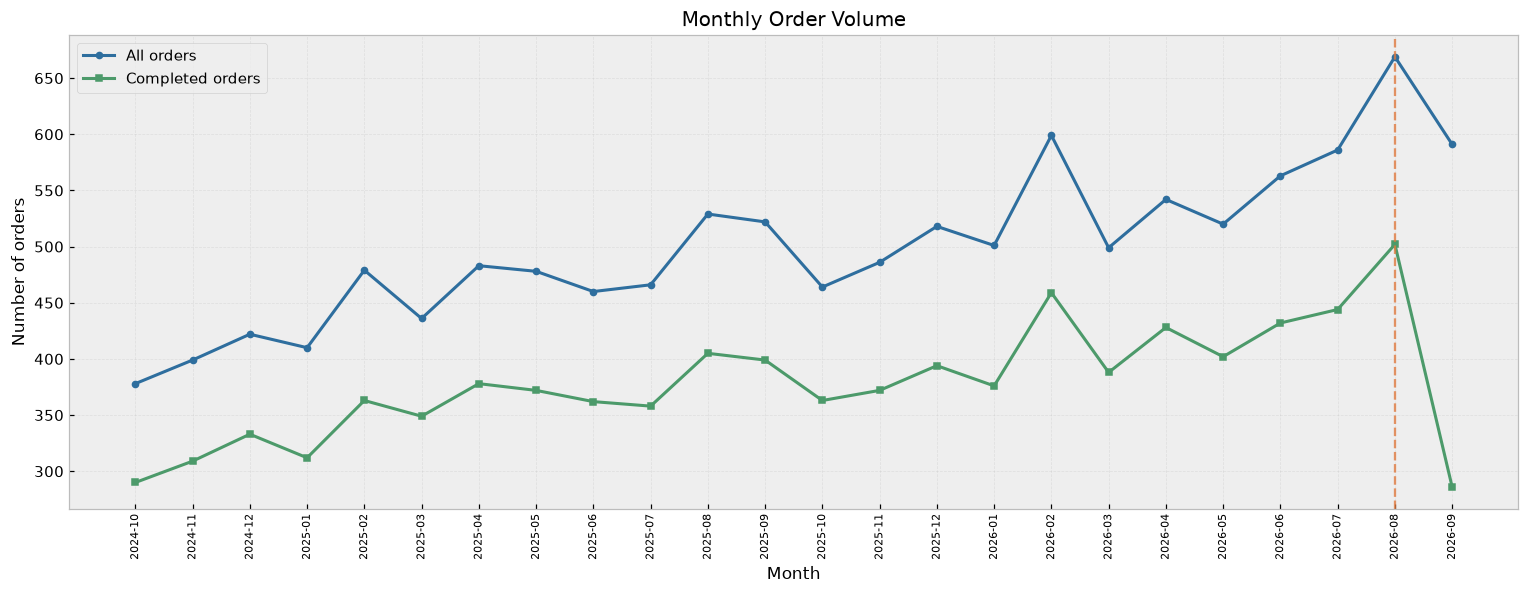

In [22]:
# Orders over time, by month and by year
orders["order_month"] = orders["order_date"].dt.to_period("M")
orders["order_year"] = orders["order_date"].dt.year

orders_by_month = (orders.groupby("order_month")
                   .agg(orders=("order_id", "count"))
                   .reset_index())
orders_by_month["order_month"] = orders_by_month["order_month"].astype(str)

orders_by_year = (orders.groupby("order_year")
                  .agg(orders=("order_id", "count"))
                  .reset_index())
completed_by_month = (orders[orders["status"] == "Completed"]
                      .groupby("order_month").size()
                      .rename("completed_orders").reset_index())
completed_by_month["order_month"] = completed_by_month["order_month"].astype(str)
orders_by_month = orders_by_month.merge(completed_by_month, on="order_month", how="left")

print("Orders per year")
print("-" * 60)
print(orders_by_year.to_string(index=False))
print()
print("Orders per month")
print("-" * 60)
print(orders_by_month.to_string(index=False))
print()
busiest = orders_by_month.loc[orders_by_month["orders"].idxmax()]
quietest = orders_by_month.loc[orders_by_month["orders"].idxmin()]
print(f"Busiest month  : {busiest['order_month']} with {busiest['orders']:,} orders")
print(f"Quietest month : {quietest['order_month']} with {quietest['orders']:,} orders")
print(f"Peak-to-trough ratio: {busiest['orders'] / quietest['orders']:.2f}x")
print()
print("Note: the last month of the window is only partly covered by the data, so it "
      "should not be read as a collapse in demand.")

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(orders_by_month["order_month"], orders_by_month["orders"],
        marker="o", markersize=4, linewidth=2, color=PALETTE[0], label="All orders")
ax.plot(orders_by_month["order_month"], orders_by_month["completed_orders"],
        marker="s", markersize=4, linewidth=2, color=PALETTE[2], label="Completed orders")
ax.set_title("Monthly Order Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orders")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.axvline(orders_by_month["orders"].idxmax(), color=PALETTE[1], linestyle="--",
           linewidth=1.5, alpha=0.8)
fig.tight_layout()
save_fig(fig, "09_monthly_order_volume")

Orders shipped to 20 cities
----------------------------------------------------------------------
                orders  share
shipping_city                
Karachi           2423   0.20
Lahore            2312   0.19
Rawalpindi        1035   0.09
Islamabad          972   0.08
Faisalabad         822   0.07
Peshawar           625   0.05
Multan             526   0.04
Gujranwala         453   0.04
Quetta             392   0.03
Hyderabad          346   0.03
Sialkot            335   0.03
Bahawalpur         335   0.03
Sukkur             253   0.02
Sargodha           246   0.02
Abbottabad         223   0.02
Sahiwal            161   0.01
Mirpur Khas        152   0.01
Mardan             137   0.01
Rahim Yar Khan     135   0.01
Gwadar             117   0.01

48.1% of all orders ship to the top 3 cities: Karachi, Lahore, Rawalpindi.


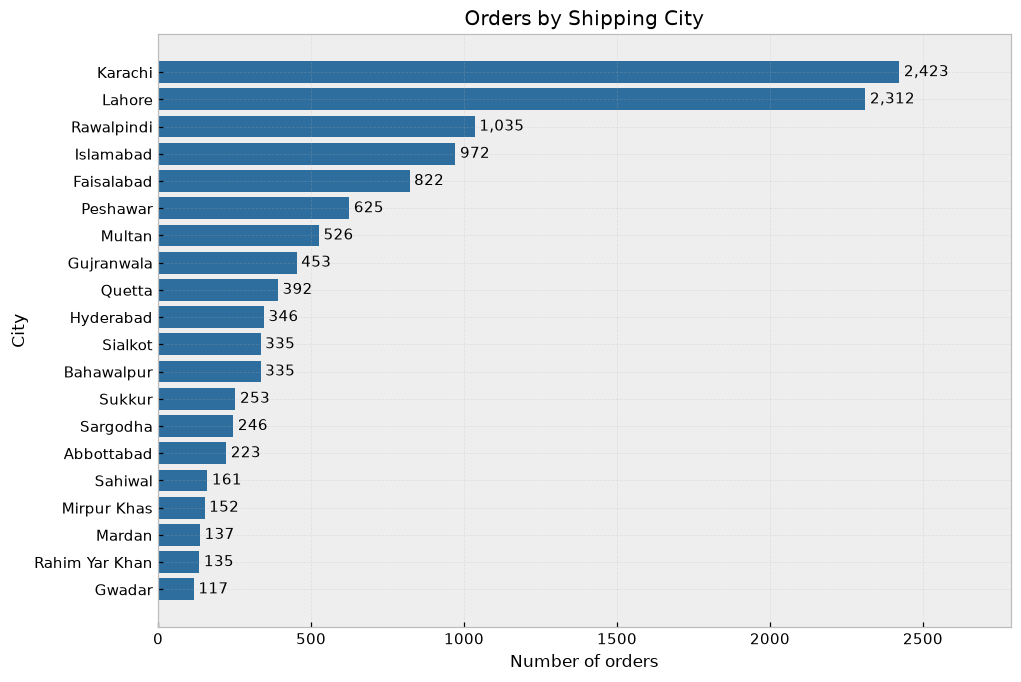

In [23]:
# Orders by shipping city
orders_by_city = (orders.groupby("shipping_city")
                  .agg(orders=("order_id", "count"))
                  .sort_values("orders", ascending=False))
orders_by_city["share"] = orders_by_city["orders"] / len(orders)

print(f"Orders shipped to {len(orders_by_city)} cities")
print("-" * 70)
print(orders_by_city.to_string())
print()
print(f"{orders_by_city['share'].head(3).sum():.1%} of all orders ship to the "
      f"top 3 cities: {', '.join(orders_by_city.index[:3])}.")

fig, ax = plt.subplots(figsize=(10, 7))
city_plot = orders_by_city.sort_values("orders")
bars = ax.barh(city_plot.index, city_plot["orders"], color=PALETTE[0])
ax.bar_label(bars, padding=3, fmt="{:,.0f}")
ax.set_title("Orders by Shipping City")
ax.set_xlabel("Number of orders")
ax.set_ylabel("City")
ax.set_xlim(0, city_plot["orders"].max() * 1.15)
save_fig(fig, "10_orders_by_city")

Orders per customer - descriptive statistics
----------------------------------------------------------------------
count   1,440.00
mean        8.33
std         6.30
min         1.00
25%         3.00
50%         7.00
75%        13.00
max        33.00

Registered customers          : 1,500
Customers who placed >=1 order : 1,440
Customers who never ordered    : 60
Customers with exactly 1 order : 132 (9.2% of active customers)
Customers with 2+ orders       : 1,308 (90.8% of active customers)
Most orders by one customer    : 33

Top 10 customers by number of orders
             orders first_order last_order
customer_id                               
CUST-00944       33  2024-11-02 2026-09-26
CUST-00618       30  2024-11-01 2026-09-23
CUST-00927       30  2024-10-10 2026-09-01
CUST-01270       27  2024-12-19 2026-09-22
CUST-00867       27  2024-11-29 2026-09-24
CUST-00290       27  2024-12-06 2026-09-07
CUST-01080       26  2024-11-03 2026-09-21
CUST-00263       26  2024-11-29 2026-09-23

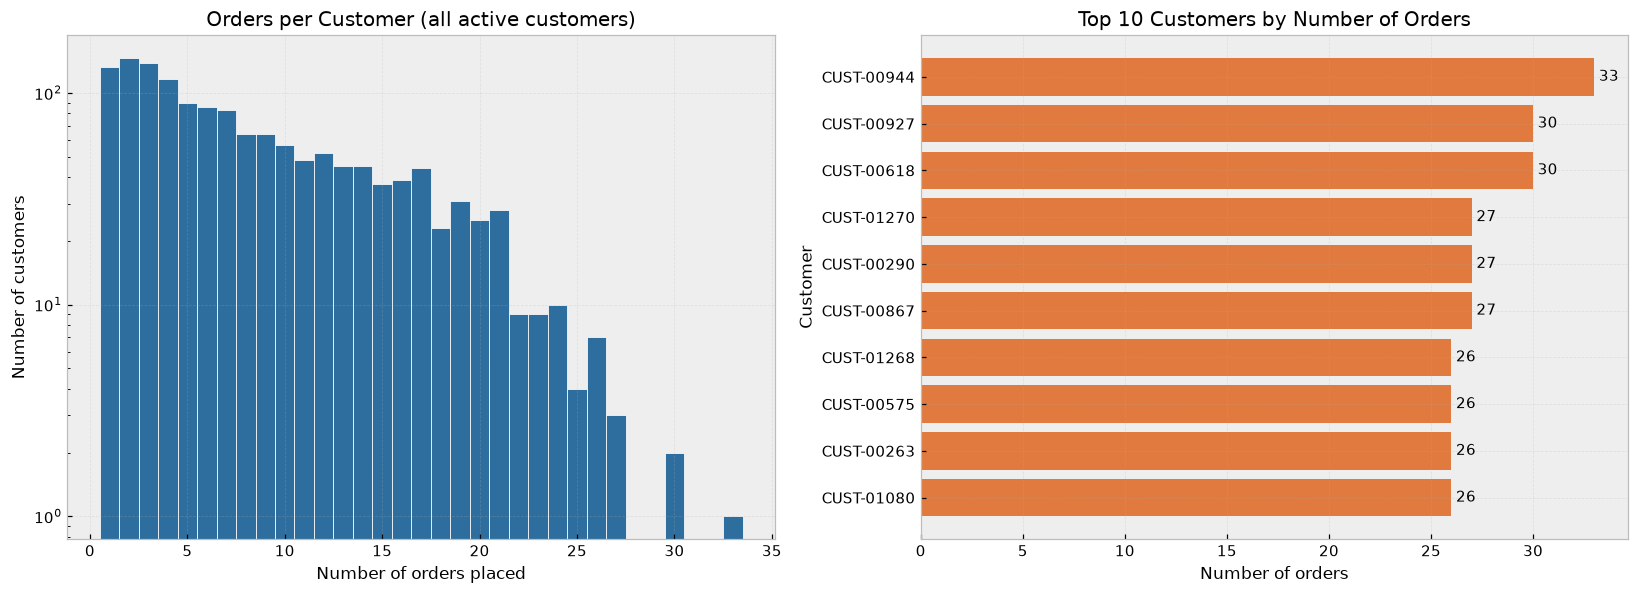

In [24]:
# Orders per customer: some customers buy often, most buy rarely
orders_per_customer = orders.groupby("customer_id").agg(
    orders=("order_id", "count"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
)
orders_per_customer = orders_per_customer.sort_values("orders", ascending=False)

all_customers = set(customers["customer_id"])
customers_with_orders = set(orders["customer_id"])
inactive_customers = sorted(all_customers - customers_with_orders)

single_order_customers = int((orders_per_customer["orders"] == 1).sum())
multi_order_customers = int((orders_per_customer["orders"] > 1).sum())

print("Orders per customer - descriptive statistics")
print("-" * 70)
print(orders_per_customer["orders"].describe().to_string())
print()
print(f"Registered customers          : {len(customers):,}")
print(f"Customers who placed >=1 order : {len(orders_per_customer):,}")
print(f"Customers who never ordered    : {len(inactive_customers):,}")
print(f"Customers with exactly 1 order : {single_order_customers:,} "
      f"({single_order_customers / len(orders_per_customer):.1%} of active customers)")
print(f"Customers with 2+ orders       : {multi_order_customers:,} "
      f"({multi_order_customers / len(orders_per_customer):.1%} of active customers)")
print(f"Most orders by one customer    : {orders_per_customer['orders'].max()}")
print()
print("Top 10 customers by number of orders")
print(orders_per_customer.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].hist(orders_per_customer["orders"], bins=range(1, 35),
             color=PALETTE[0], edgecolor="white", align="left")
axes[0].set_title("Orders per Customer (all active customers)")
axes[0].set_xlabel("Number of orders placed")
axes[0].set_ylabel("Number of customers")
axes[0].set_yscale("log")

top10 = orders_per_customer.head(10).sort_values("orders")
axes[1].barh(top10.index, top10["orders"], color=PALETTE[1])
axes[1].set_title("Top 10 Customers by Number of Orders")
axes[1].set_xlabel("Number of orders")
axes[1].set_ylabel("Customer")
axes[1].bar_label(axes[1].containers[0], padding=3, fmt="{:,.0f}")

fig.tight_layout()
save_fig(fig, "11_orders_per_customer")

## Section 9: Order Item Analysis

`order_items.csv` holds one row per product line inside an order. This is
the most important table for money, because it holds the quantity, the price
actually charged, and the discount.

### Revenue formula

The dataset deliberately does **not** store an order total. Revenue per line
is calculated as:

```
revenue = quantity * unit_price * (1 - discount_percent / 100)
```

The result is added as a new in-memory column (`line_revenue`). The original
CSV file is never modified, and nothing is written back to disk.

Worked example: `quantity=2`, `unit_price=1,000`, `discount_percent=10`
gives `2 * 1,000 * 0.90 = 1,800 PKR`.

In [25]:
print("order_items shape :", order_items.shape)
print("columns           :", list(order_items.columns))
print()
print(order_items.dtypes.to_string())
print()
print("Missing values per column:")
print(order_items.isna().sum().to_string())
print()
print("Fully duplicated rows     :", int(order_items.duplicated().sum()))
print("Duplicate order_item_id   :", int(order_items["order_item_id"].duplicated().sum()))
print(f"Distinct orders in items  : {order_items['order_id'].nunique():,}")
print(f"Distinct products sold    : {order_items['product_id'].nunique():,}")

order_items shape : (30006, 6)
columns           : ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount_percent']

order_item_id           str
order_id                str
product_id              str
quantity              int64
unit_price          float64
discount_percent      int64

Missing values per column:
order_item_id       0
order_id            0
product_id          0
quantity            0
unit_price          0
discount_percent    0

Fully duplicated rows     : 0
Duplicate order_item_id   : 0
Distinct orders in items  : 12,000
Distinct products sold    : 300


Product lines per order
----------------------------------------------------------------------
count   12,000.00
mean         2.50
std          1.50
min          1.00
25%          1.00
50%          2.00
75%          3.00
max          6.00

Number of orders by line count
----------------------------------------------------------------------
1    4066
2    2988
3    2036
4    1357
5     890
6     663

Most orders contain a single product line (33.9%), but the largest orders contain 6 different products.


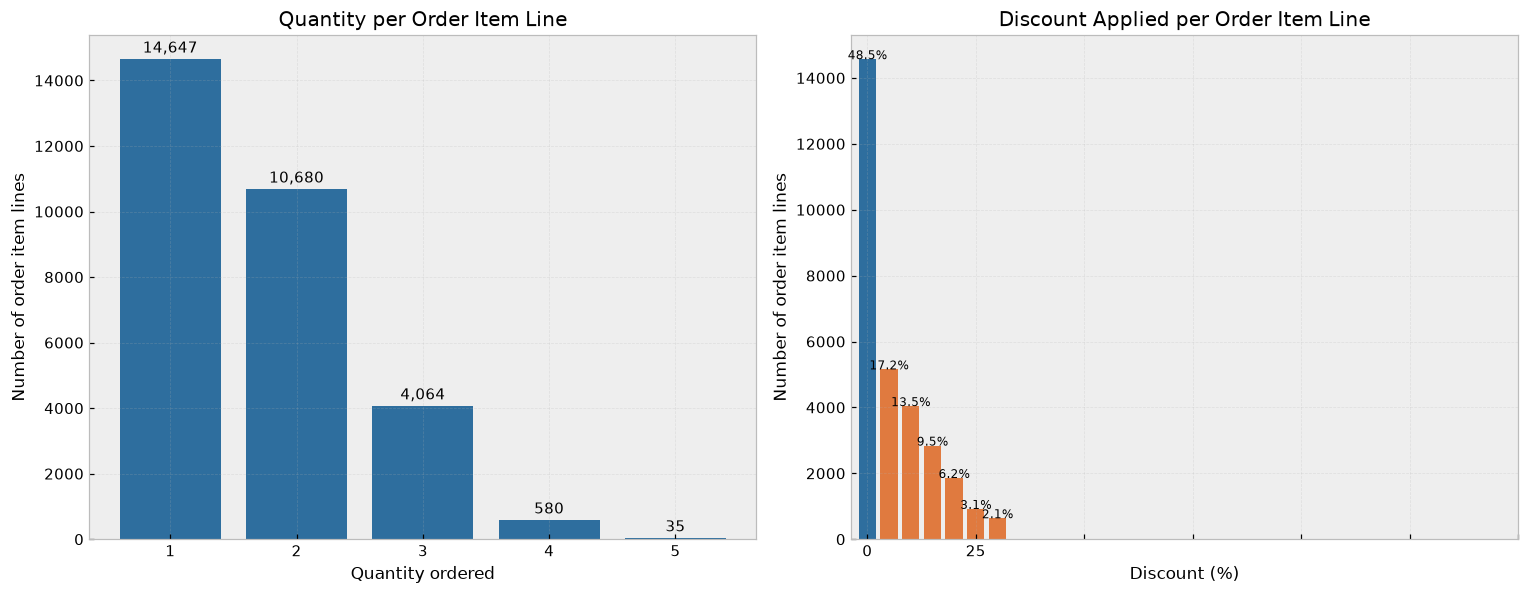

In [26]:
lines_per_order = order_items.groupby("order_id").size()
print("Product lines per order")
print("-" * 70)
print(lines_per_order.describe().to_string())
print()
print("Number of orders by line count")
print("-" * 70)
print(lines_per_order.value_counts().sort_index().rename("orders").to_string())
print()
print(f"Most orders contain a single product line "
      f"({(lines_per_order == 1).mean():.1%}), but the largest orders contain "
      f"{lines_per_order.max()} different products.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

quantity_counts = order_items["quantity"].value_counts().sort_index()
axes[0].bar(quantity_counts.index.astype(str), quantity_counts.values, color=PALETTE[0])
axes[0].set_title("Quantity per Order Item Line")
axes[0].set_xlabel("Quantity ordered")
axes[0].set_ylabel("Number of order item lines")
axes[0].bar_label(axes[0].containers[0], padding=2, fmt="{:,.0f}")

discount_counts = (order_items["discount_percent"].value_counts()
                   .sort_index())
discount_share = discount_counts / len(order_items)
colors = [PALETTE[1] if value > 0 else PALETTE[0] for value in discount_counts.index]
axes[1].bar(discount_counts.index.astype(str), discount_counts.values, color=colors)
axes[1].set_title("Discount Applied per Order Item Line")
axes[1].set_xlabel("Discount (%)")
axes[1].set_ylabel("Number of order item lines")
for position, (value, share) in enumerate(zip(discount_counts.values, discount_share)):
    axes[1].text(position, value, f"\n{share:.1%}", ha="center", fontsize=8)
axes[1].set_xticks(discount_counts.index)

fig.tight_layout()
save_fig(fig, "12_quantity_and_discount_distribution")

In [27]:
# Revenue per line, calculated in memory only
order_items["line_revenue"] = (
    order_items["quantity"]
    * order_items["unit_price"]
    * (1 - order_items["discount_percent"] / 100)
)

print("Revenue per order item line (PKR)")
print("-" * 70)
print(order_items["line_revenue"].describe().to_string())
print()
print(f"Total revenue across all order lines : PKR {order_items['line_revenue'].sum():,.0f}")
print(f"Total quantity sold                  : {order_items['quantity'].sum():,} units")
print()
print("Worked check - first 3 lines")
print("-" * 70)
check_rows = order_items.head(3)[["quantity", "unit_price", "discount_percent", "line_revenue"]]
print(check_rows.to_string(index=False))
first = order_items.iloc[0]
manual = first["quantity"] * first["unit_price"] * (1 - first["discount_percent"] / 100)
print(f"\nManual check on line 1: {first['quantity']} x {first['unit_price']:,.2f} x "
      f"(1 - {first['discount_percent']}/100) = {manual:,.2f} -> matches stored value "
      f"{first['line_revenue']:,.2f}: {abs(manual - first['line_revenue']) < 0.01}")

Revenue per order item line (PKR)
----------------------------------------------------------------------
count      30,006.00
mean       28,174.38
std        70,577.88
min           117.30
25%         2,132.73
50%         5,872.92
75%        15,894.38
max     1,392,523.00

Total revenue across all order lines : PKR 845,400,583
Total quantity sold                  : 50,694 units

Worked check - first 3 lines
----------------------------------------------------------------------
 quantity  unit_price  discount_percent  line_revenue
        1    4,394.80                 0      4,394.80
        1  184,940.79                10    166,446.71
        2    3,733.83                10      6,720.89

Manual check on line 1: 1 x 4,394.80 x (1 - 0/100) = 4,394.80 -> matches stored value 4,394.80: True


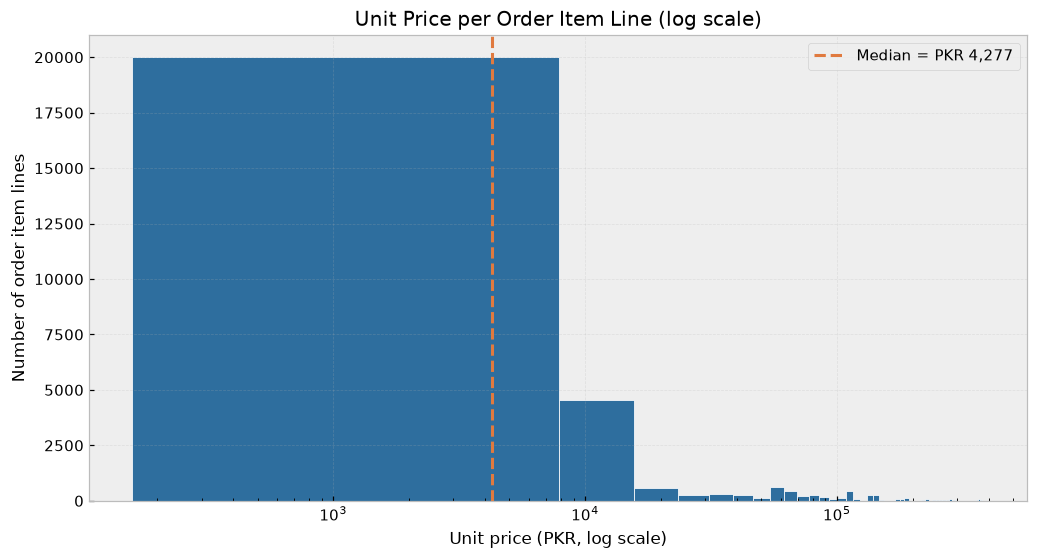

In [28]:
# Unit price distribution
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(order_items["unit_price"], bins=50, color=PALETTE[0], edgecolor="white")
ax.set_xscale("log")
ax.axvline(order_items["unit_price"].median(), color=PALETTE[1], linestyle="--",
           linewidth=2, label=f"Median = PKR {order_items['unit_price'].median():,.0f}")
ax.set_title("Unit Price per Order Item Line (log scale)")
ax.set_xlabel("Unit price (PKR, log scale)")
ax.set_ylabel("Number of order item lines")
ax.legend()
save_fig(fig, "13_unit_price_distribution")

Top 15 products by number of order lines
--------------------------------------------------------------------------------------------------------------
product_id  order_lines                      product_name           category     price
 PROD-0252          700                   EBM Peanut Pack            Grocery    780.00
 PROD-0268          687  Dalda Basmati Rice 5kg Hardcover            Grocery  2,200.00
 PROD-0154          614           Clean & Clear Face Wash             Beauty  8,500.00
 PROD-0241          594  My First Activity Book Hardcover              Books  2,400.00
 PROD-0130          455                        Zara Shawl            Fashion  7,800.00
 PROD-0213          444              Reebok Sports Jacket             Sports  3,650.00
 PROD-0285          429                Felix Coffee Table     Home & Kitchen  9,950.00
 PROD-0230          414       Computer Science Algorithms              Books  4,350.00
 PROD-0251          414            Continental Chocolatto        

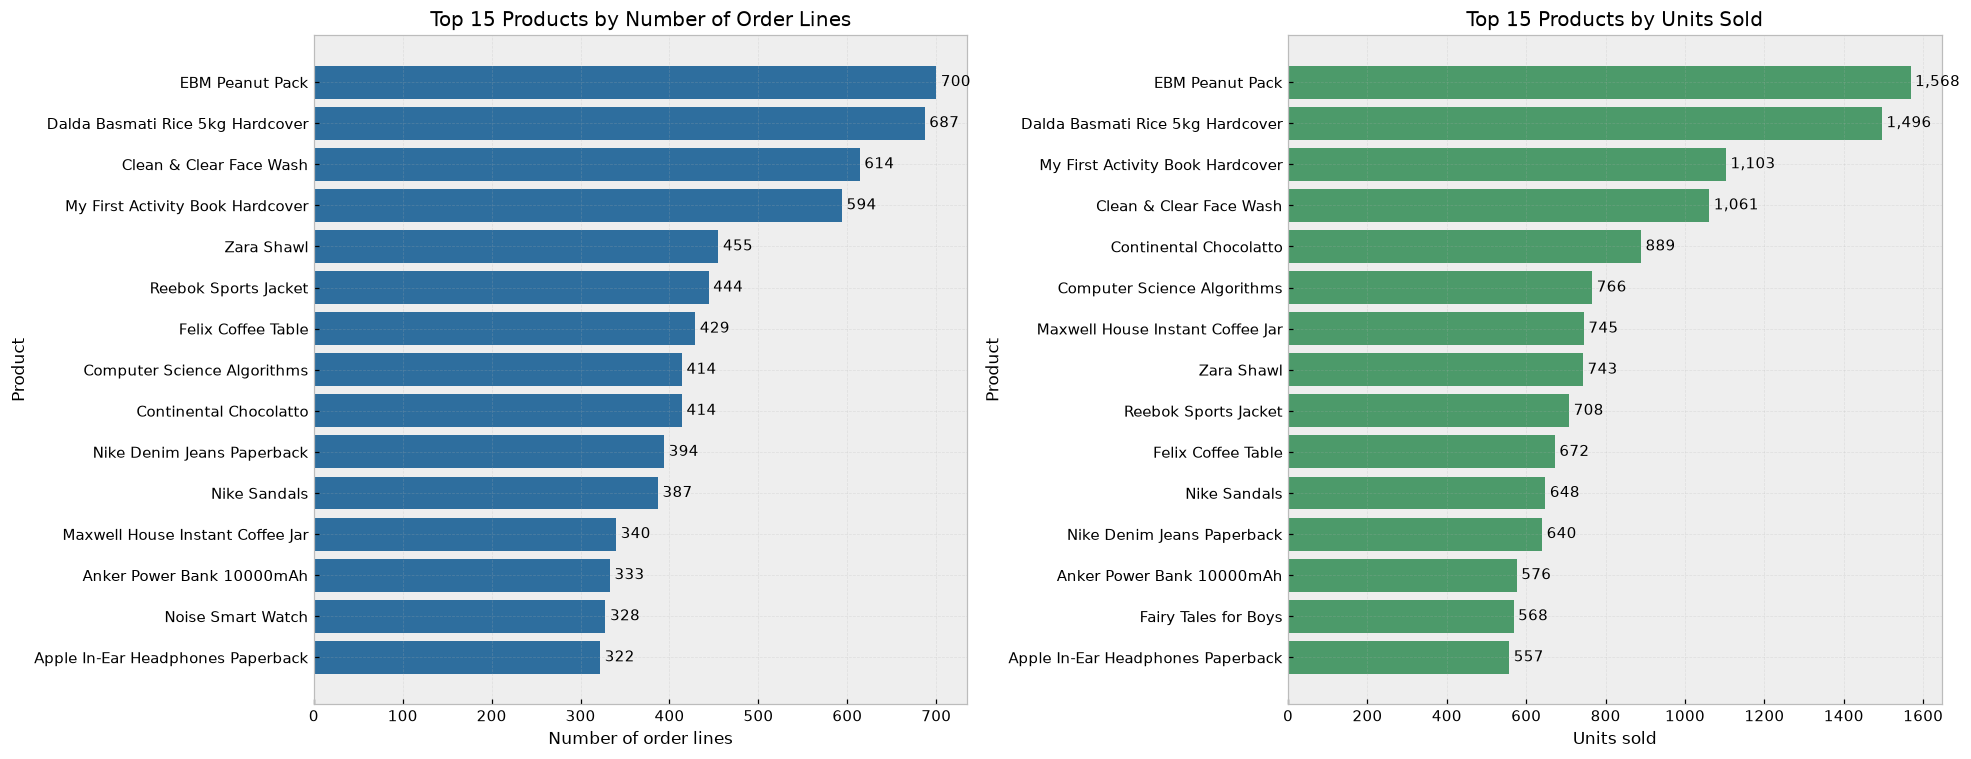

In [29]:
# Most frequently purchased products, by number of order lines
top_by_frequency = (order_items["product_id"].value_counts()
                    .head(15).rename_axis("product_id").reset_index(name="order_lines"))

# Most units sold
top_by_quantity = (order_items.groupby("product_id")
                   .agg(units_sold=("quantity", "sum"),
                        order_lines=("order_item_id", "count"))
                   .sort_values("units_sold", ascending=False)
                   .head(15).reset_index())

# Add readable product names by joining to the product catalogue
top_by_frequency = top_by_frequency.merge(
    products[["product_id", "product_name", "category", "price"]],
    on="product_id", how="left",
)
top_by_quantity = top_by_quantity.merge(
    products[["product_id", "product_name", "category", "price"]],
    on="product_id", how="left",
)

print("Top 15 products by number of order lines")
print("-" * 110)
print(top_by_frequency.to_string(index=False))
print()
print("Top 15 products by units sold")
print("-" * 110)
print(top_by_quantity.to_string(index=False))
print()
print("Note that these two rankings are not the same. A product can appear in "
      "many orders with quantity 1 and still sell fewer units than a product "
      "that appears in fewer orders with a large quantity each time.")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

freq_plot = top_by_frequency.iloc[::-1]
axes[0].barh(freq_plot["product_name"], freq_plot["order_lines"], color=PALETTE[0])
axes[0].set_title("Top 15 Products by Number of Order Lines")
axes[0].set_xlabel("Number of order lines")
axes[0].set_ylabel("Product")
axes[0].bar_label(axes[0].containers[0], padding=3, fmt="{:,.0f}")

qty_plot = top_by_quantity.iloc[::-1]
axes[1].barh(qty_plot["product_name"], qty_plot["units_sold"], color=PALETTE[2])
axes[1].set_title("Top 15 Products by Units Sold")
axes[1].set_xlabel("Units sold")
axes[1].set_ylabel("Product")
axes[1].bar_label(axes[1].containers[0], padding=3, fmt="{:,.0f}")

fig.tight_layout()
save_fig(fig, "14_top_products_by_frequency_and_quantity")

## Section 10: Payment Analysis

`payments.csv` has exactly one row per order. It answers *how* the customer
paid and whether the money actually arrived.

In [30]:
print("payments shape :", payments.shape)
print("columns        :", list(payments.columns))
print()
print(payments.dtypes.to_string())
print()
print("Missing values per column:")
print(payments.isna().sum().to_string())
print()
print("Fully duplicated rows  :", int(payments.duplicated().sum()))
print("Duplicate payment_id   :", int(payments["payment_id"].duplicated().sum()))
print("Duplicate order_id     :", int(payments["order_id"].duplicated().sum()))
print()
print(f"Payment date range : {payments['payment_date'].min().date()} to "
      f"{payments['payment_date'].max().date()}")

payments shape : (12000, 5)
columns        : ['payment_id', 'order_id', 'payment_method', 'payment_status', 'payment_date']

payment_id                   str
order_id                     str
payment_method               str
payment_status               str
payment_date      datetime64[us]

Missing values per column:
payment_id        0
order_id          0
payment_method    0
payment_status    0
payment_date      0

Fully duplicated rows  : 0
Duplicate payment_id   : 0
Duplicate order_id     : 0

Payment date range : 2024-10-01 to 2026-09-26


Payment method distribution
----------------------------------------------------------------------
Cash on Delivery      3,305    27.5%  ###############
Credit Card           3,119    26.0%  ##############
JazzCash              1,903    15.9%  ########
Debit Card            1,856    15.5%  ########
EasyPaisa             1,107     9.2%  #####
Bank Transfer           710     5.9%  ###

Payment status distribution
----------------------------------------------------------------------
Paid                  8,731    72.8%  ########################################
Refunded              1,676    14.0%  #######
Pending               1,027     8.6%  ####
Failed                  566     4.7%  ##

Only 72.8% of payment records have a 'Paid' status, because cancelled orders fail, returned orders are refunded, and recent orders are still pending.


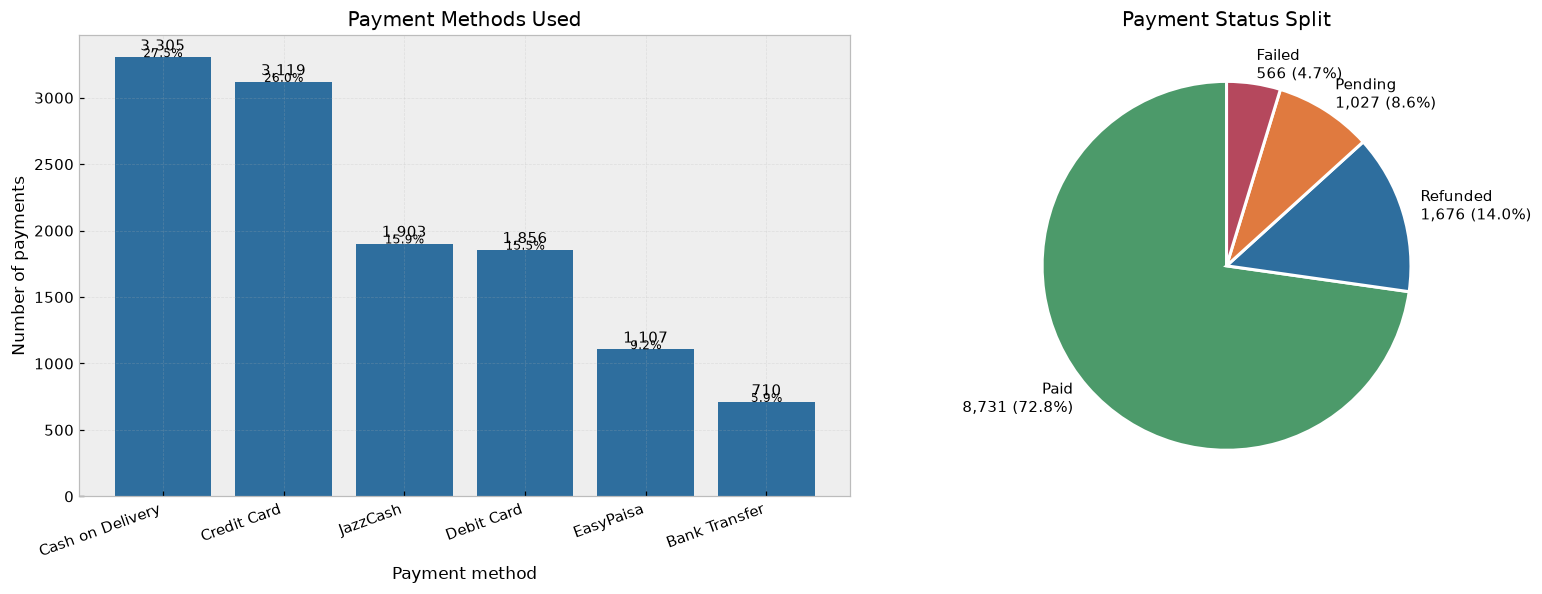

In [31]:
method_counts = payments["payment_method"].value_counts()
method_share = payments["payment_method"].value_counts(normalize=True)
pay_status_counts = payments["payment_status"].value_counts()
pay_status_share = payments["payment_status"].value_counts(normalize=True)

print("Payment method distribution")
print("-" * 70)
for method, count in method_counts.items():
    print(f"{method:<20}{count:>7,}{method_share[method]:>9.1%}  "
          f"{'#' * int(method_share[method] * 55)}")

print()
print("Payment status distribution")
print("-" * 70)
for status, count in pay_status_counts.items():
    print(f"{status:<20}{count:>7,}{pay_status_share[status]:>9.1%}  "
          f"{'#' * int(pay_status_share[status] * 55)}")

paid_rate = pay_status_share.get("Paid", 0)
print()
print(f"Only {paid_rate:.1%} of payment records have a 'Paid' status, because "
      f"cancelled orders fail, returned orders are refunded, and recent orders "
      f"are still pending.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

method_plot = method_counts.sort_values(ascending=False)
axes[0].bar(method_plot.index, method_plot.values, color=PALETTE[0])
axes[0].set_title("Payment Methods Used")
axes[0].set_xlabel("Payment method")
axes[0].set_ylabel("Number of payments")
axes[0].bar_label(axes[0].containers[0], padding=2, fmt="{:,.0f}")
for position, value in enumerate(method_plot.values):
    axes[0].text(position, value, f"\n{value / len(payments):.1%}",
                 ha="center", fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

status_plot = pay_status_counts.sort_values(ascending=False)
axes[1].pie(
    status_plot.values,
    labels=[f"{label}\n{value:,} ({value / len(payments):.1%})"
            for label, value in status_plot.items()],
    colors=[PALETTE[2], PALETTE[0], PALETTE[1], PALETTE[3]],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Payment Status Split")

fig.tight_layout()
save_fig(fig, "15_payment_methods_and_status")

Order status (rows) vs payment status (columns)
------------------------------------------------------------------------------------------
payment_status  Failed  Paid  Pending  Refunded
status                                         
Cancelled          566     0        0       208
Completed            0  8441        0       635
Pending              0   193     1027         0
Returned             0    97        0       833

Row percentages show how each order status resolves at the payment stage.
payment_status  Failed  Paid  Pending  Refunded
status                                         
Cancelled        73.10  0.00     0.00     26.90
Completed         0.00 93.00     0.00      7.00
Pending           0.00 15.80    84.20      0.00
Returned          0.00 10.40     0.00     89.60

The relationship behaves exactly as a real store would expect: completed orders are almost always paid, cancelled orders mostly fail, and returned orders are almost entirely refunded.


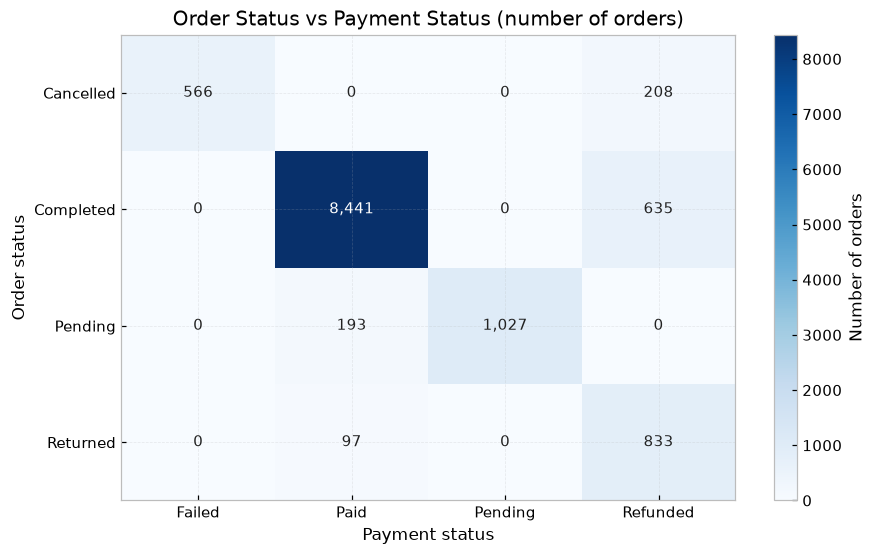

In [32]:
# Order status vs payment status.
# This is the most useful table in the payment section: it shows whether the
# payment system behaves the way a real shop would expect.
# IMPORTANT: the two tables are merged on order_id first. Using crosstab on the
# two raw frames would rely on the rows happening to line up, which is not
# something the code should assume.
status_payment = orders[["order_id", "status"]].merge(
    payments[["order_id", "payment_status"]], on="order_id", how="left",
    validate="one_to_one",
)
order_status_vs_payment = pd.crosstab(status_payment["status"],
                                      status_payment["payment_status"])

print("Order status (rows) vs payment status (columns)")
print("-" * 90)
print(order_status_vs_payment.to_string())
print()
print("Row percentages show how each order status resolves at the payment stage.")
print((order_status_vs_payment.div(order_status_vs_payment.sum(axis=1), axis=0) * 100)
      .round(1).to_string())
print()
print("The relationship behaves exactly as a real store would expect: completed "
      "orders are almost always paid, cancelled orders mostly fail, and returned "
      "orders are almost entirely refunded.")

fig, ax = plt.subplots(figsize=(9, 5.5))
image = ax.imshow(order_status_vs_payment.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(order_status_vs_payment.columns)), order_status_vs_payment.columns)
ax.set_yticks(range(len(order_status_vs_payment.index)), order_status_vs_payment.index)
ax.set_xlabel("Payment status")
ax.set_ylabel("Order status")
ax.set_title("Order Status vs Payment Status (number of orders)")
for row in range(order_status_vs_payment.shape[0]):
    for column in range(order_status_vs_payment.shape[1]):
        value = order_status_vs_payment.values[row, column]
        colour = "white" if value > order_status_vs_payment.values.max() * 0.6 else "#222222"
        ax.text(column, row, f"{value:,}", ha="center", va="center", color=colour)
fig.colorbar(image, ax=ax, label="Number of orders")
save_fig(fig, "16_order_status_vs_payment_status")

## Section 11: Combining the Data with Pandas Merges

The five tables are separate on purpose. To answer business questions the
rows have to be brought together. This section builds one analysis-ready
table called `sales`, one row per order item line.

### Why each merge is needed

| Merge | Type | Why |
| --- | --- | --- |
| `order_items` + `products` | many-to-one | adds `category`, `brand` and `cost` so revenue can be split by product and profit can be calculated |
| result + `orders` | many-to-one | adds `order_date`, `status` and `shipping_city` so revenue can be filtered to successful orders and grouped by time/city |
| result + `customers` | many-to-one | adds `city`, `gender`, `age` and `signup_date` so revenue can be analysed by customer segment |
| `orders` + `payments` | one-to-one | adds payment method and payment status for the payment analysis |

### The most common merge mistake

Joining `orders` to `order_items` and then joining `products` **before**
collapsing to one row per order would multiply rows: one order with 3 lines
becomes 3 rows, and joining products again would not multiply further only
because each line has exactly one product. The danger is joining two tables
that both have several rows per order, which silently inflates the row count
and every total computed from it.

The protection used here is to check the row count **before and after** every
merge, and to use `validate=` so Pandas raises an error if a key is not what
the merge expects.

One naming detail matters. `products.csv` has a column called `price`, but
`order_items.csv` also has `unit_price`. These are not the same thing:

* `unit_price` is what was actually charged on that line
* `products.price` is the current catalogue price

They differ on almost every line in this dataset, which is normal for a shop
whose prices move over time. To stop the two being confused, the product
column is renamed to `list_price` during the merge. All revenue calculations
use `unit_price`, because that is the money actually received.

In [33]:
# Start from the order item lines - the most granular table
sales = order_items.copy()
rows_before = len(sales)
print(f"Starting point: order_items, {rows_before:,} rows, {sales.shape[1]} columns\n")

# ---- Merge 1: add product information (many-to-one) ----------------------
# products has one row per product_id, so this must not change the row count.
sales = sales.merge(
    products.rename(columns={"price": "list_price"}),
    on="product_id",
    how="left",
    validate="many_to_one",
)
assert len(sales) == rows_before, "Merge 1 changed the row count!"
print(f"After merge 1 (add products): {len(sales):,} rows "
      f"(unchanged: {len(sales) == rows_before}), {sales.shape[1]} columns")
print("  added: product_name, category, subcategory, brand, list_price, cost,")
print("         profit_per_unit, margin_percent, stock_quantity")

# ---- Merge 2: add order information (many-to-one) ------------------------
orders_for_merge = orders.drop(columns=["order_month", "order_year"])
rows_before = len(sales)
sales = sales.merge(orders_for_merge, on="order_id", how="left", validate="many_to_one")
assert len(sales) == rows_before, "Merge 2 changed the row count!"
print(f"\nAfter merge 2 (add orders): {len(sales):,} rows "
      f"(unchanged: {len(sales) == rows_before}), {sales.shape[1]} columns")
print("  added: customer_id, order_date, status, shipping_city")

# ---- Merge 3: add customer information (many-to-one) ---------------------
customers_for_merge = customers.rename(
    columns={"city": "customer_city", "name": "customer_name"}
)
rows_before = len(sales)
sales = sales.merge(customers_for_merge, on="customer_id", how="left",
                    validate="many_to_one")
assert len(sales) == rows_before, "Merge 3 changed the row count!"
print(f"\nAfter merge 3 (add customers): {len(sales):,} rows "
      f"(unchanged: {len(sales) == rows_before}), {sales.shape[1]} columns")
print("  added: customer_name, email, gender, age, customer_city, signup_date")

# ---- Derived measures that need cost from products -----------------------
# The discount reduces the price actually received, so it also reduces the
# profit. Cost is not discounted.
sales["line_revenue"] = sales["line_revenue"]  # already calculated in section 9
sales["line_cost"] = sales["quantity"] * sales["cost"]
sales["line_profit"] = sales["line_revenue"] - sales["line_cost"]
sales["order_month"] = sales["order_date"].dt.to_period("M")
sales["order_year"] = sales["order_date"].dt.year

print(f"\nFinal analysis table 'sales': {len(sales):,} rows x {sales.shape[1]} columns")
print("No merge multiplied the row count, so every total below is correct.")

Starting point: order_items, 30,006 rows, 7 columns

After merge 1 (add products): 30,006 rows (unchanged: True), 16 columns
  added: product_name, category, subcategory, brand, list_price, cost,
         profit_per_unit, margin_percent, stock_quantity

After merge 2 (add orders): 30,006 rows (unchanged: True), 20 columns
  added: customer_id, order_date, status, shipping_city

After merge 3 (add customers): 30,006 rows (unchanged: True), 26 columns
  added: customer_name, email, gender, age, customer_city, signup_date

Final analysis table 'sales': 30,006 rows x 30 columns
No merge multiplied the row count, so every total below is correct.


In [34]:
# Proof that the merge did not multiply rows
print("MERGE SAFETY CHECKS")
print("-" * 78)
checks = pd.DataFrame([
    {"Check": "order_items row count", "Value": f"{len(order_items):,}"},
    {"Check": "sales row count (must match)", "Value": f"{len(sales):,}"},
    {"Check": "Distinct order_id in sales", "Value": f"{sales['order_id'].nunique():,}"},
    {"Check": "Distinct order_id in orders", "Value": f"{orders['order_id'].nunique():,}"},
    {"Check": "Distinct product_id in sales", "Value": f"{sales['product_id'].nunique():,}"},
    {"Check": "Distinct product_id in products", "Value": f"{products['product_id'].nunique():,}"},
    {"Check": "Rows with missing category", "Value": f"{int(sales['category'].isna().sum()):,}"},
    {"Check": "Rows with missing cost", "Value": f"{int(sales['cost'].isna().sum()):,}"},
    {"Check": "Rows with missing order status", "Value": f"{int(sales['status'].isna().sum()):,}"},
])
print(checks.to_string(index=False))
print()
print("Revenue is identical whether computed before or after the merges, which "
      "confirms no rows were duplicated or dropped:")
print(f"  order_items revenue : PKR {order_items['line_revenue'].sum():,.2f}")
print(f"  sales revenue       : PKR {sales['line_revenue'].sum():,.2f}")
print(f"  difference          : PKR {abs(order_items['line_revenue'].sum() - sales['line_revenue'].sum()):,.6f}")

MERGE SAFETY CHECKS
------------------------------------------------------------------------------
                          Check  Value
          order_items row count 30,006
   sales row count (must match) 30,006
     Distinct order_id in sales 12,000
    Distinct order_id in orders 12,000
   Distinct product_id in sales    300
Distinct product_id in products    300
     Rows with missing category      0
         Rows with missing cost      0
 Rows with missing order status      0

Revenue is identical whether computed before or after the merges, which confirms no rows were duplicated or dropped:
  order_items revenue : PKR 845,400,583.33
  sales revenue       : PKR 845,400,583.33
  difference          : PKR 0.000000


In [35]:
# The order-level table, built separately for order-level metrics.
# Starting from orders (12,000 rows) and merging payments one-to-one is safe
# because payments also has exactly one row per order.
order_level = orders_for_merge.merge(payments, on="order_id", how="left",
                                     validate="one_to_one")
assert len(order_level) == len(orders), "Order-level merge changed the row count!"

# One row per order: total revenue and total profit for that order
order_totals = (sales.groupby("order_id")
                .agg(order_revenue=("line_revenue", "sum"),
                     order_profit=("line_profit", "sum"),
                     order_units=("quantity", "sum"),
                     order_lines=("order_item_id", "count"))
                .reset_index())

order_level = order_level.merge(order_totals, on="order_id", how="left",
                                validate="one_to_one")
print(f"Order-level table: {len(order_level):,} rows x {order_level.shape[1]} columns")
print("One row per order, with its total revenue, total profit, units and line count.")
order_level.head(5).to_string(index=False)

Order-level table: 12,000 rows x 13 columns
One row per order, with its total revenue, total profit, units and line count.


'  order_id customer_id order_date    status shipping_city payment_id   payment_method payment_status payment_date  order_revenue  order_profit  order_units  order_lines\nORD-000001  CUST-00340 2024-10-01 Completed    Faisalabad PAY-000001         JazzCash           Paid   2024-10-03       4,394.80        994.80            1            1\nORD-000002  CUST-01491 2024-10-01 Completed       Karachi PAY-000002      Credit Card       Refunded   2024-10-03     166,446.71     59,446.71            1            1\nORD-000003  CUST-00466 2024-10-01 Completed       Sialkot PAY-000003         JazzCash           Paid   2024-10-02       7,010.88      1,040.88            3            2\nORD-000004  CUST-01392 2024-10-01 Completed        Multan PAY-000004 Cash on Delivery           Paid   2024-10-05     166,260.13     48,150.13            4            4\nORD-000005  CUST-00591 2024-10-01 Completed        Quetta PAY-000005 Cash on Delivery           Paid   2024-10-05       4,396.09        426.09       

## Section 12: Business Metrics

### How cancelled, returned and pending orders are treated

This is the part of an e-commerce analysis that is most often done
incorrectly, so the treatment is stated explicitly before any number is
calculated.

| Order status | Treatment | Reason |
| --- | --- | --- |
| **Completed** | counted as revenue and profit | the sale actually completed |
| **Cancelled** | excluded from revenue and profit | the customer never paid for it |
| **Returned** | excluded from revenue and profit | the goods came back, so there is no sale |
| **Pending** | excluded from revenue and profit | the outcome is not known yet |

Two revenue figures are therefore reported for every metric:

* **Gross revenue** - every order line, whatever the status. This is what
was ordered in total.
* **Realised revenue** - completed orders only. This is the money the
business actually keeps, and it is the figure used for all rankings
(top categories, top cities, AOV).

Profit uses the same rule. Profit per line is:

```
line_profit = revenue - (quantity * cost)
```

The discount reduces revenue, and cost is not discounted, so a heavily
discounted sale earns less profit on the same product.

In [36]:
def metrics(status_filter=None):
    """Return the sales rows for a given order status (None = every order)."""
    return sales if status_filter is None else sales[sales["status"] == status_filter]


def order_count(status_filter=None):
    """Count distinct orders, optionally filtered by order status."""
    frame = orders if status_filter is None else orders[orders["status"] == status_filter]
    return int(frame["order_id"].nunique())


completed = metrics("Completed")
cancelled = metrics("Cancelled")
returned = metrics("Returned")
pending = metrics("Pending")

gross_revenue = sales["line_revenue"].sum()
realised_revenue = completed["line_revenue"].sum()
gross_profit = sales["line_profit"].sum()
realised_profit = completed["line_profit"].sum()

total_orders = order_count()
total_customers = int(customers["customer_id"].nunique())
active_customers = int(orders["customer_id"].nunique())
inactive_customers = total_customers - active_customers
total_products = int(products["product_id"].nunique())
total_units = int(sales["quantity"].sum())
completed_units = int(completed["quantity"].sum())

completed_orders = order_count("Completed")
aov_realised = realised_revenue / completed_orders
aov_gross = gross_revenue / total_orders
avg_items_per_order = len(sales) / total_orders
avg_units_per_order = total_units / total_orders
avg_profit_per_order = realised_profit / completed_orders
cancellation_rate = order_count("Cancelled") / total_orders
return_rate = order_count("Returned") / total_orders
pending_rate = order_count("Pending") / total_orders

orders_per_customer_series = orders.groupby("customer_id").size()
repeat_customers = int((orders_per_customer_series > 1).sum())
one_time_customers = int((orders_per_customer_series == 1).sum())
repeat_customer_rate = repeat_customers / active_customers
repeat_order_share = (
    orders[orders["customer_id"].isin(
        orders_per_customer_series[orders_per_customer_series > 1].index
    )].shape[0] / total_orders
)

print("=" * 92)
print("BUSINESS METRICS")
print("=" * 92)

print("\n-- Volume --")
print(f"Total orders                     : {total_orders:>14,}")
print(f"Total customers registered       : {total_customers:>14,}")
print(f"Active customers (>=1 order)     : {active_customers:>14,}")
print(f"Inactive customers (0 orders)    : {inactive_customers:>14,}")
print(f"Total products                   : {total_products:>14,}")
print(f"Order item lines                 : {len(sales):>14,}")
print(f"Total units sold (all orders)    : {total_units:>14,}")
print(f"Total units sold (completed)     : {completed_units:>14,}")

print("\n-- Revenue and profit (PKR) --")
print(f"{'Gross revenue (all orders)':<44}: {gross_revenue:>18,.0f}")
print(f"{'Realised revenue (completed)':<44}: {realised_revenue:>18,.0f}")
print(f"{'Revenue lost to cancelled':<44}: {cancelled['line_revenue'].sum():>18,.0f}")
print(f"{'Revenue lost to returned':<44}: {returned['line_revenue'].sum():>18,.0f}")
print(f"{'Revenue still pending':<44}: {pending['line_revenue'].sum():>18,.0f}")
print(f"{'Gross profit (all orders)':<44}: {gross_profit:>18,.0f}")
print(f"{'Realised profit (completed)':<44}: {realised_profit:>18,.0f}")
print(f"{'Realised profit margin':<44}: {realised_profit / realised_revenue:>17.2%}")

print("\n-- Average order behaviour --")
print(f"{'Average order value (completed orders)':<44}: {aov_realised:>18,.0f}")
print(f"{'Average order value (all orders)':<44}: {aov_gross:>18,.0f}")
print(f"{'Average profit per completed order':<44}: {avg_profit_per_order:>18,.0f}")
print(f"{'Average product lines per order':<44}: {avg_items_per_order:>18.2f}")
print(f"{'Average units per order':<44}: {avg_units_per_order:>18.2f}")

print("\n-- Order outcome rates --")
print(f"{'Cancellation rate':<44}: {cancellation_rate:>17.2%}")
print(f"{'Return rate':<44}: {return_rate:>17.2%}")
print(f"{'Pending rate':<44}: {pending_rate:>17.2%}")
print(f"{'Completion rate':<44}: {completed_orders / total_orders:>17.2%}")

print("\n-- Customer loyalty --")
print(f"{'Repeat customers (2+ orders)':<44}: {repeat_customers:>14,}")
print(f"{'One-time customers':<44}: {one_time_customers:>14,}")
print(f"{'Repeat customer rate (of active)':<44}: {repeat_customer_rate:>17.2%}")
print(f"{'Share of orders from repeat customers':<44}: {repeat_order_share:>17.2%}")
print("=" * 92)

BUSINESS METRICS

-- Volume --
Total orders                     :         12,000
Total customers registered       :          1,500
Active customers (>=1 order)     :          1,440
Inactive customers (0 orders)    :             60
Total products                   :            300
Order item lines                 :         30,006
Total units sold (all orders)    :         50,694
Total units sold (completed)     :         38,406

-- Revenue and profit (PKR) --
Gross revenue (all orders)                  :        845,400,583
Realised revenue (completed)                :        632,578,306
Revenue lost to cancelled                   :         59,450,592
Revenue lost to returned                    :         68,659,441
Revenue still pending                       :         84,712,245
Gross profit (all orders)                   :        262,533,363
Realised profit (completed)                 :        196,295,406
Realised profit margin                      :            31.03%

-- Average order 

In [37]:
# Store the headline metrics in a table so they can be reused in the findings
headline_metrics = {
    "Total orders": f"{total_orders:,}",
    "Registered customers": f"{total_customers:,}",
    "Active customers": f"{active_customers:,}",
    "Inactive customers": f"{inactive_customers:,}",
    "Total products": f"{total_products:,}",
    "Total units sold": f"{total_units:,}",
    "Gross revenue (PKR)": f"{gross_revenue:,.0f}",
    "Realised revenue (PKR)": f"{realised_revenue:,.0f}",
    "Realised profit (PKR)": f"{realised_profit:,.0f}",
    "Realised profit margin": f"{realised_profit / realised_revenue:.2%}",
    "Average order value (PKR)": f"{aov_realised:,.0f}",
    "Average profit per order (PKR)": f"{avg_profit_per_order:,.0f}",
    "Average units per order": f"{avg_units_per_order:.2f}",
    "Cancellation rate": f"{cancellation_rate:.2%}",
    "Return rate": f"{return_rate:.2%}",
    "Pending rate": f"{pending_rate:.2%}",
    "Repeat customer rate": f"{repeat_customer_rate:.2%}",
}
print("HEADLINE METRICS")
for metric, value in headline_metrics.items():
    print(f"  {metric:<36} {value}")

HEADLINE METRICS
  Total orders                         12,000
  Registered customers                 1,500
  Active customers                     1,440
  Inactive customers                   60
  Total products                       300
  Total units sold                     50,694
  Gross revenue (PKR)                  845,400,583
  Realised revenue (PKR)               632,578,306
  Realised profit (PKR)                196,295,406
  Realised profit margin               31.03%
  Average order value (PKR)            69,698
  Average profit per order (PKR)       21,628
  Average units per order              4.22
  Cancellation rate                    6.45%
  Return rate                          7.75%
  Pending rate                         10.17%
  Repeat customer rate                 90.83%


In [38]:
# The revenue reconciliation: gross revenue split by what happened to the order.
# This proves the three parts add back up to the gross figure.
reconciliation = pd.DataFrame({
    "orders": [
        order_count("Completed"), order_count("Cancelled"),
        order_count("Returned"), order_count("Pending"),
    ],
    "revenue_pkr": [
        completed["line_revenue"].sum(), cancelled["line_revenue"].sum(),
        returned["line_revenue"].sum(), pending["line_revenue"].sum(),
    ],
    "profit_pkr": [
        completed["line_profit"].sum(), cancelled["line_profit"].sum(),
        returned["line_profit"].sum(), pending["line_profit"].sum(),
    ],
}, index=["Completed", "Cancelled", "Returned", "Pending"])

reconciliation["revenue_share"] = reconciliation["revenue_pkr"] / gross_revenue
print("REVENUE RECONCILIATION - gross revenue split by order status")
print("-" * 92)
print(reconciliation.to_string())
print("-" * 92)
print(f"{'TOTAL':<14}{reconciliation['orders'].sum():>8,}"
      f"{reconciliation['revenue_pkr'].sum():>22,.0f}"
      f"{reconciliation['profit_pkr'].sum():>22,.0f}")
print()
print(f"Completed + cancelled + returned + pending revenue = "
      f"PKR {reconciliation['revenue_pkr'].sum():,.0f}, which equals gross revenue "
      f"of PKR {gross_revenue:,.0f}. The split is complete, so no revenue is lost "
      f"or double counted.")

REVENUE RECONCILIATION - gross revenue split by order status
--------------------------------------------------------------------------------------------
           orders    revenue_pkr     profit_pkr  revenue_share
Completed    9076 632,578,305.60 196,295,405.60           0.75
Cancelled     774  59,450,591.87  18,509,801.87           0.07
Returned      930  68,659,441.14  21,323,281.14           0.08
Pending      1220  84,712,244.72  26,404,874.72           0.10
--------------------------------------------------------------------------------------------
TOTAL           12,000           845,400,583           262,533,363

Completed + cancelled + returned + pending revenue = PKR 845,400,583, which equals gross revenue of PKR 845,400,583. The split is complete, so no revenue is lost or double counted.


## Section 13: Business Questions

Each question is answered with a calculation, and the answer is printed with
the supporting numbers so the result can be checked. All revenue and profit
figures below use **completed orders only**, following the rule set out in
Section 12.

### Q1. Which product categories generate the most revenue?

In [39]:
revenue_by_category = (completed.groupby("category")
                       .agg(revenue=("line_revenue", "sum"),
                            profit=("line_profit", "sum"),
                            units=("quantity", "sum"),
                            order_lines=("order_item_id", "count"))
                       .sort_values("revenue", ascending=False))
revenue_by_category["revenue_share"] = revenue_by_category["revenue"] / realised_revenue
revenue_by_category["margin_percent"] = (
    revenue_by_category["profit"] / revenue_by_category["revenue"] * 100
)

print("Revenue, profit and margin by category (completed orders)")
print("-" * 118)
print(revenue_by_category.to_string())
print()
top_category = revenue_by_category.index[0]
print(f"ANSWER: {top_category} generates the most revenue at PKR "
      f"{revenue_by_category['revenue'].iloc[0]:,.0f} "
      f"({revenue_by_category['revenue_share'].iloc[0]:.1%} of realised revenue).")
print(f"The bottom three categories together "
      f"({', '.join(revenue_by_category.index[-3:])}) account for only "
      f"{revenue_by_category['revenue_share'].tail(3).sum():.1%} of realised revenue.")

Revenue, profit and margin by category (completed orders)
----------------------------------------------------------------------------------------------------------------------
                          revenue        profit  units  order_lines  revenue_share  margin_percent
category                                                                                          
Electronics        177,321,318.73 63,852,068.73   2594         1918           0.28           36.01
Home Appliances    158,512,077.59 44,890,527.59   1529         1140           0.25           28.32
Computers          153,812,523.67 49,477,073.67   2422         1812           0.24           32.17
Home & Kitchen      42,028,660.26 13,371,440.26   2720         1715           0.07           31.82
Fashion             26,808,739.67  7,058,939.67   4917         2954           0.04           26.33
Mobile Accessories  21,893,346.44  6,089,126.44   5231         3053           0.03           27.81
Sports              18,580,377.

### Q2 and Q3. Which products sell the most units, and which generate the most revenue?

In [40]:
product_performance = (completed.groupby("product_id")
                       .agg(units_sold=("quantity", "sum"),
                            revenue=("line_revenue", "sum"),
                            profit=("line_profit", "sum"),
                            order_lines=("order_item_id", "count")))
product_performance = product_performance.merge(
    products[["product_id", "product_name", "category", "price", "margin_percent"]],
    on="product_id", how="left",
).rename(columns={"price": "list_price"})
product_performance["revenue_per_unit"] = (
    product_performance["revenue"] / product_performance["units_sold"]
)

top5_revenue = product_performance.sort_values("revenue", ascending=False).head(5)
top5_units = product_performance.sort_values("units_sold", ascending=False).head(5)

print("Q2 - Top 5 products by units sold (completed orders)")
print("-" * 118)
print(top5_units[["product_name", "category", "units_sold", "revenue",
                   "revenue_per_unit"]].to_string(index=False))
print()
print("Q3 - Top 5 products by revenue (completed orders)")
print("-" * 118)
print(top5_revenue[["product_name", "category", "units_sold", "revenue",
                    "revenue_per_unit"]].to_string(index=False))
print()

best_units_product = top5_units.index[0]
best_revenue_product = top5_revenue.index[0]
print(f"ANSWER Q2: '{product_performance.loc[best_units_product, 'product_name']}' "
      f"({product_performance.loc[best_units_product, 'category']}) sells the most units "
      f"at {product_performance.loc[best_units_product, 'units_sold']:,} units.")
print(f"ANSWER Q3: '{product_performance.loc[best_revenue_product, 'product_name']}' "
      f"({product_performance.loc[best_revenue_product, 'category']}) generates the most "
      f"revenue at PKR {product_performance.loc[best_revenue_product, 'revenue']:,.0f}.")
print()
overlap = set(top5_units.index) & set(top5_revenue.index)
if overlap:
    print(f"{len(overlap)} of the 5 products appear in BOTH lists "
          f"({', '.join(product_performance.loc[sorted(overlap), 'product_name'])}).")
else:
    print("The two lists share NO products at all. Unit sales and revenue rank "
          "products completely differently, because a cheap high-volume item and an "
          "expensive low-volume item cannot both lead on price and on quantity.")
print()
print(f"Price per unit actually received, for comparison:")
print(f"  volume leader  : {product_performance.loc[best_units_product, 'product_name']} "
      f"-> PKR {product_performance.loc[best_units_product, 'revenue_per_unit']:,.0f} per unit")
print(f"  revenue leader : {product_performance.loc[best_revenue_product, 'product_name']} "
      f"-> PKR {product_performance.loc[best_revenue_product, 'revenue_per_unit']:,.0f} per unit")
print(f"That is a "
      f"{product_performance.loc[best_revenue_product, 'revenue_per_unit'] / product_performance.loc[best_units_product, 'revenue_per_unit']:,.0f}x "
      f"difference in price per unit, which is why the rankings do not match.")

Q2 - Top 5 products by units sold (completed orders)
----------------------------------------------------------------------------------------------------------------------
                    product_name category  units_sold      revenue  revenue_per_unit
                 EBM Peanut Pack  Grocery        1190   864,300.72            726.30
Dalda Basmati Rice 5kg Hardcover  Grocery        1124 2,295,443.82          2,042.21
My First Activity Book Hardcover    Books         817 1,824,387.15          2,233.03
         Clean & Clear Face Wash   Beauty         775 6,131,474.97          7,911.58
          Continental Chocolatto  Grocery         696   965,703.08          1,387.50

Q3 - Top 5 products by revenue (completed orders)
----------------------------------------------------------------------------------------------------------------------
                      product_name        category  units_sold       revenue  revenue_per_unit
        Polaroid Mirrorless Camera     Electronics   

### Q4. Which cities generate the most revenue?

In [41]:
revenue_by_city = (completed.groupby("shipping_city")
                   .agg(revenue=("line_revenue", "sum"),
                        orders=("order_id", "nunique"),
                        profit=("line_profit", "sum"),
                        units=("quantity", "sum"))
                   .sort_values("revenue", ascending=False))
revenue_by_city["revenue_share"] = revenue_by_city["revenue"] / realised_revenue
revenue_by_city["aov"] = revenue_by_city["revenue"] / revenue_by_city["orders"]

print("Revenue by shipping city (completed orders)")
print("-" * 118)
print(revenue_by_city.to_string())
print()
best_city = revenue_by_city.index[0]
print(f"ANSWER: {best_city} generates the most revenue at PKR "
      f"{revenue_by_city['revenue'].iloc[0]:,.0f} "
      f"({revenue_by_city['revenue_share'].iloc[0]:.1%} of realised revenue) from "
      f"{revenue_by_city['orders'].iloc[0]:,} completed orders.")
print(f"The top 5 cities together generate "
      f"{revenue_by_city['revenue_share'].head(5).sum():.1%} of realised revenue, "
      f"while the bottom 5 cities generate only "
      f"{revenue_by_city['revenue_share'].tail(5).sum():.1%}.")

Revenue by shipping city (completed orders)
----------------------------------------------------------------------------------------------------------------------
                      revenue  orders        profit  units  revenue_share       aov
shipping_city                                                                      
Karachi        123,442,173.68    1859 37,973,983.68   7892           0.20 66,402.46
Lahore         119,768,642.21    1782 38,202,692.21   7575           0.19 67,210.24
Islamabad       58,203,133.39     738 16,858,623.39   3220           0.09 78,866.03
Rawalpindi      53,986,138.92     776 16,444,148.92   3065           0.09 69,569.77
Faisalabad      44,305,556.38     607 14,399,886.38   2577           0.07 72,991.03
Peshawar        30,569,226.18     465  9,230,996.18   1977           0.05 65,740.27
Multan          27,186,463.79     383  7,770,323.79   1613           0.04 70,982.93
Gujranwala      24,609,979.32     335  7,382,599.32   1451           0.04 73,462.

### Q5. Which customers spend the most?

In [42]:
spend_by_customer = (completed.groupby("customer_id")
                     .agg(revenue=("line_revenue", "sum"),
                          orders=("order_id", "nunique"),
                          units=("quantity", "sum"),
                          last_order=("order_date", "max"))
                     .merge(customers_for_merge[["customer_id", "customer_name",
                                                 "customer_city", "gender", "age"]],
                            on="customer_id", how="left", validate="many_to_one")
                     .set_index("customer_id")
                     .sort_values("revenue", ascending=False))
spend_by_customer["aov"] = spend_by_customer["revenue"] / spend_by_customer["orders"]

print("Top 10 customers by total spend (completed orders)")
print("-" * 118)
print(spend_by_customer.head(10)[
    ["customer_name", "customer_city", "orders", "units", "revenue", "aov", "last_order"]
].to_string())
print()
print("Spend distribution across all customers who have spent")
print("-" * 118)
print(spend_by_customer["revenue"].describe().to_string())
print()
print(f"Note: this table covers the {len(spend_by_customer):,} customers with at least "
      f"one COMPLETED order. It is smaller than the {active_customers:,} active customers, "
      f"because {active_customers - len(spend_by_customer):,} customers have orders but none "
      f"of them completed, so they have no realised spend to report.")
print()

top_spender = spend_by_customer.index[0]
top10_spend_share = spend_by_customer["revenue"].head(10).sum() / realised_revenue
median_spend = spend_by_customer["revenue"].median()
print(f"ANSWER: '{spend_by_customer.loc[top_spender, 'customer_name']}' ({top_spender}) "
      f"from {spend_by_customer.loc[top_spender, 'customer_city']} spent the most at PKR "
      f"{spend_by_customer.loc[top_spender, 'revenue']:,.0f} over "
      f"{int(spend_by_customer.loc[top_spender, 'orders'])} orders.")
print(f"The top 10 spenders account for {top10_spend_share:.2%} of realised revenue.")
print(f"The median customer spent PKR {median_spend:,.0f}, so spending is heavily "
      f"skewed: the average customer ({spend_by_customer['revenue'].mean():,.0f}) "
      f"spends {(spend_by_customer['revenue'].mean() / median_spend):.1f}x the median.")

Top 10 customers by total spend (completed orders)
----------------------------------------------------------------------------------------------------------------------
              customer_name customer_city  orders  units      revenue        aov last_order
customer_id                                                                                
CUST-00977      Kiran Akram       Karachi      22    119 3,068,387.48 139,472.16 2026-09-09
CUST-00846      Kiran Kazmi        Lahore      16     86 2,437,941.70 152,371.36 2026-07-25
CUST-01023      Alia Sattar        Quetta      19     77 2,290,703.59 120,563.35 2026-09-14
CUST-01270   Danial Bukhari      Peshawar      24    107 2,288,179.05  95,340.79 2026-09-22
CUST-00216   Javeria Sattar      Sargodha      19     90 2,273,512.49 119,658.55 2026-05-22
CUST-01386     Nimra Shafiq    Faisalabad       6     35 2,160,352.12 360,058.69 2026-09-09
CUST-01080      Nimra Iqbal     Islamabad      22     97 2,091,742.97  95,079.23 2026-08-27
CU


Spend distribution across all customers who have spent
----------------------------------------------------------------------------------------------------------------------
count       1,387.00
mean      456,076.64
std       451,006.26
min           380.91
25%       107,782.32
50%       324,089.68
75%       667,009.25
max     3,068,387.48

Note: this table covers the 1,387 customers with at least one COMPLETED order. It is smaller than the 1,440 active customers, because 53 customers have orders but none of them completed, so they have no realised spend to report.

ANSWER: 'Kiran Akram' (CUST-00977) from Karachi spent the most at PKR 3,068,387 over 22 orders.
The top 10 spenders account for 3.60% of realised revenue.
The median customer spent PKR 324,090, so spending is heavily skewed: the average customer (456,077) spends 1.4x the median.


### Q6 and Q7. What is the monthly revenue trend, and which months are busiest?

In [43]:
monthly = (completed.groupby("order_month")
           .agg(revenue=("line_revenue", "sum"),
                profit=("line_profit", "sum"),
                orders=("order_id", "nunique"),
                units=("quantity", "sum"))
           .reset_index())
monthly["order_month"] = monthly["order_month"].astype(str)
monthly["aov"] = monthly["revenue"] / monthly["orders"]

print("Monthly revenue and profit (completed orders)")
print("-" * 118)
print(monthly.to_string(index=False))
print()

revenue_month = monthly.loc[monthly["revenue"].idxmax()]
orders_month = monthly.loc[monthly["orders"].idxmax()]
lowest_month = monthly.loc[monthly["revenue"].idxmin()]

# --- Handling the partial final month --------------------------------------
# The dataset stops part way through the last month, and orders placed in the
# final days are still 'Pending' rather than 'Completed'. The last month is
# therefore NOT comparable with a full month, and is excluded from the trend
# comparison below.
last_order_date = orders["order_date"].max()
final_month = last_order_date.to_period("M")
final_month_is_partial = last_order_date < final_month.end_time.normalize()
monthly_complete = monthly[monthly["order_month"] != str(final_month)]
lowest_complete_month = monthly_complete.loc[monthly_complete["revenue"].idxmin()]
monthly_complete = monthly_complete.reset_index(drop=True)

print(f"ANSWER Q6: The highest-revenue month is {revenue_month['order_month']} at PKR "
      f"{revenue_month['revenue']:,.0f}. The lowest COMPLETE month is "
      f"{lowest_complete_month['order_month']} at PKR {lowest_complete_month['revenue']:,.0f}.")

print()
print(f"PARTIAL MONTH WARNING")
print(f"  The data ends on {last_order_date.date()}, part way through "
      f"{final_month}.")
print(f"  {monthly.loc[monthly['order_month'] == str(final_month), 'revenue'].iloc[0]:,.0f} PKR "
      f"of revenue is recorded in {final_month}, but it covers only part of the month AND "
      f"orders from the last few days are still Pending, so few of them count as Completed.")
print(f"  The final month is therefore EXCLUDED from the trend comparison below. Comparing it "
      f"directly with a full month would understate revenue and could suggest a false decline.")

# --- Trend over complete months only ---------------------------------------
first_window = monthly_complete.head(6)
last_window = monthly_complete.tail(6)
first_window_avg = first_window["revenue"].mean()
last_window_avg = last_window["revenue"].mean()
growth_ratio = last_window_avg / first_window_avg

print()
print("Revenue trend, comparing only complete months")
print("-" * 118)
print(f"First 6 complete months ({first_window['order_month'].iloc[0]} to "
      f"{first_window['order_month'].iloc[-1]}): average PKR {first_window_avg:,.0f} per month")
print(f"Last  6 complete months ({last_window['order_month'].iloc[0]} to "
      f"{last_window['order_month'].iloc[-1]}): average PKR {last_window_avg:,.0f} per month")
print(f"Change over the two-year window: {growth_ratio:.2f}x "
      f"({(growth_ratio - 1):+.1%})")
print()
print(f"Average monthly revenue across the {len(monthly_complete)} complete months is PKR "
      f"{monthly_complete['revenue'].mean():,.0f}. The best month is "
      f"{(revenue_month['revenue'] / monthly_complete['revenue'].mean() - 1):+.1%} against that "
      f"average and the worst complete month is "
      f"{(lowest_complete_month['revenue'] / monthly_complete['revenue'].mean() - 1):+.1%}.")
print()
print("Monthly revenue moves around a rising trend rather than climbing every month. "
      "The month-to-month swings are large, so any single month is a weak guide to the "
      "underlying direction; the six-month averages above are the more reliable read.")
print()
print(f"ANSWER Q7: The busiest month by completed order count is {orders_month['order_month']} "
      f"with {int(orders_month['orders']):,} completed orders.")
busiest_by_orders_all = orders_by_month.loc[orders_by_month["orders"].idxmax()]
print(f"Counting every status rather than completed only, the busiest month is "
      f"{busiest_by_orders_all['order_month']} with {int(busiest_by_orders_all['orders']):,} orders.")

Monthly revenue and profit (completed orders)


----------------------------------------------------------------------------------------------------------------------
order_month       revenue        profit  orders  units       aov
    2024-10 20,987,008.23  7,218,388.23     290   1190 72,368.99
    2024-11 19,784,087.33  6,198,007.33     309   1306 64,026.17
    2024-12 19,818,096.39  6,250,486.39     333   1437 59,513.80
    2025-01 23,382,787.50  7,204,907.50     312   1405 74,944.83
    2025-02 27,249,924.21  8,564,544.21     363   1530 75,068.66
    2025-03 25,885,639.18  8,244,279.18     349   1540 74,170.89
    2025-04 28,941,280.09  9,431,080.09     378   1749 76,564.23
    2025-05 26,274,473.17  7,688,143.17     372   1618 70,630.30
    2025-06 23,936,610.43  7,483,800.43     362   1564 66,123.23
    2025-07 24,048,148.73  7,623,428.73     358   1442 67,173.60
    2025-08 30,035,143.65  9,967,183.65     405   1728 74,160.85
    2025-09 31,404,138.75  9,695,858.75     399   1624 78,707.11
    2025-10 27,216,005.68  8,701,39

### Q8. What is the relationship between discounts and revenue?

In [44]:
discount_bands = pd.cut(completed["discount_percent"],
                       bins=[-0.01, 0, 5, 10, 15, 20, 25, 30],
                       labels=["0%", "1-5%", "6-10%", "11-15%", "16-20%", "21-25%", "26-30%"])
discount_effect = (completed.groupby(discount_bands, observed=True)
                   .agg(order_lines=("order_item_id", "count"),
                        avg_quantity=("quantity", "mean"),
                        avg_unit_price=("unit_price", "mean"),
                        total_revenue=("line_revenue", "sum"),
                        revenue_per_line=("line_revenue", "mean"),
                        total_units=("quantity", "sum"))
                   .reset_index())
discount_effect["revenue_share"] = (
    discount_effect["total_revenue"] / discount_effect["total_revenue"].sum()
)

print("Discount vs revenue behaviour (completed orders)")
print("-" * 126)
print(discount_effect.to_string(index=False))
print()

no_discount = discount_effect.iloc[0]
max_discount = discount_effect.iloc[-1]
units_ratio = max_discount["avg_quantity"] / no_discount["avg_quantity"]
revenue_per_line_ratio = max_discount["revenue_per_line"] / no_discount["revenue_per_line"]
quantity_spread = discount_effect["avg_quantity"].max() - discount_effect["avg_quantity"].min()
total_discount_given_away = (
    completed["line_revenue"] /
    (1 - completed["discount_percent"] / 100) * (completed["discount_percent"] / 100)
).sum()

print("ANSWER: In this data, discounts reduce revenue and do NOT buy extra volume.")
print(f"  * Revenue per line falls as the discount rises: PKR "
      f"{no_discount['revenue_per_line']:,.0f} on undiscounted lines down to PKR "
      f"{max_discount['revenue_per_line']:,.0f} on 26-30% lines, a drop to "
      f"{revenue_per_line_ratio:.2f}x.")
print(f"  * Average quantity per line barely moves: {no_discount['avg_quantity']:.2f} units "
      f"undiscounted versus {max_discount['avg_quantity']:.2f} units at 26-30% off "
      f"({units_ratio:.2f}x). Across all seven discount bands the average quantity only "
      f"varies by {quantity_spread:.2f} units.")
print(f"  * So there is no evidence here that a bigger discount makes customers buy more. "
      f"The two effects that a discount is normally expected to produce are not both "
      f"present: the price falls, the volume does not rise.")
print(f"  * The value given away as discounts on completed orders is PKR "
      f"{total_discount_given_away:,.0f}, which is "
      f"{total_discount_given_away / (realised_revenue + total_discount_given_away):.2%} of the "
      f"revenue before discounts.")
print(f"  * Conclusion: as used in this period, discounting is a cost rather than a growth "
      f"tool - it reduces revenue and margin per line without a measurable increase in "
      f"units sold. Whether that is worth it cannot be settled from these tables alone, "
      f"because orders that were never placed are not visible in the data.")

Discount vs revenue behaviour (completed orders)
------------------------------------------------------------------------------------------------------------------------------
discount_percent  order_lines  avg_quantity  avg_unit_price  total_revenue  revenue_per_line  total_units  revenue_share
              0%        11002          1.69       20,876.47 321,946,619.12         29,262.55        18576           0.51
            1-5%         3893          1.70       20,324.69 103,667,202.81         26,629.13         6635           0.16
           6-10%         3058          1.70       22,753.17  86,791,499.62         28,381.79         5189           0.14
          11-15%         2141          1.71       22,581.17  57,734,570.86         26,966.17         3664           0.09
          16-20%         1415          1.66       21,206.56  34,667,732.93         24,500.16         2353           0.05
          21-25%          702          1.71       21,608.60  16,273,665.40         23,181.86      

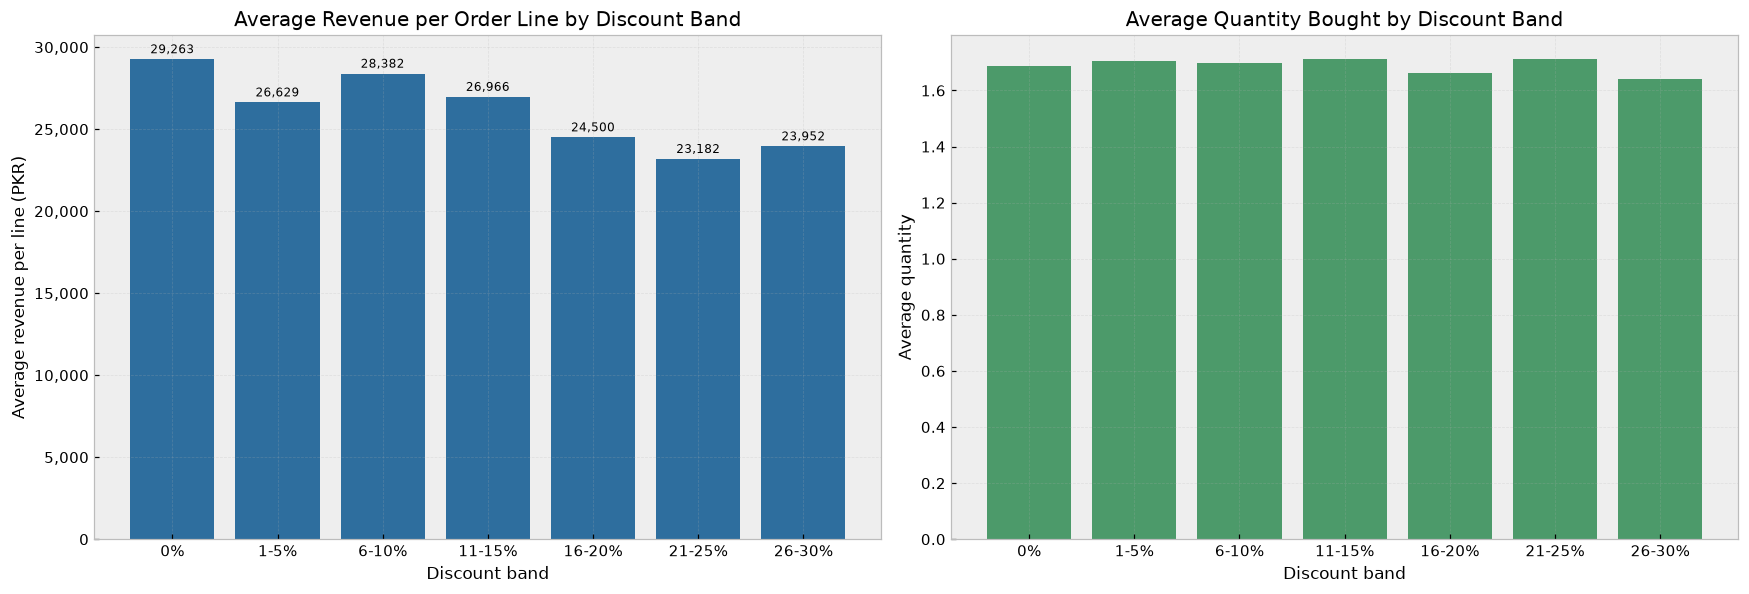

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

band_labels = discount_effect["discount_percent"].astype(str)
axes[0].bar(band_labels, discount_effect["revenue_per_line"], color=PALETTE[0])
axes[0].set_title("Average Revenue per Order Line by Discount Band")
axes[0].set_xlabel("Discount band")
axes[0].set_ylabel("Average revenue per line (PKR)")
money_axis(axes[0])
axes[0].bar_label(axes[0].containers[0], padding=2, fmt="{:,.0f}", fontsize=8)

axes[1].bar(band_labels, discount_effect["avg_quantity"], color=PALETTE[2])
axes[1].set_title("Average Quantity Bought by Discount Band")
axes[1].set_xlabel("Discount band")
axes[1].set_ylabel("Average quantity")

fig.tight_layout()
save_fig(fig, "17_discount_effect_on_revenue")

### Q9. Which categories have the highest profit margins?

In [46]:
# Two different margins are reported, because they answer different questions:
#   catalogue margin - the margin printed on the product
#   realised margin  - the margin actually achieved after discounts
realised_margin = (completed.groupby("category")
                   .agg(revenue=("line_revenue", "sum"),
                        cost=("line_cost", "sum"),
                        profit=("line_profit", "sum")))
catalogue_margin = products.groupby("category")["margin_percent"].mean()
realised_margin["catalogue_margin_percent"] = catalogue_margin
realised_margin["realised_margin_percent"] = (
    realised_margin["profit"] / realised_margin["revenue"] * 100
)
realised_margin = realised_margin.sort_values("realised_margin_percent", ascending=False)
realised_margin["revenue"] = realised_margin["revenue"].round(0)

print("Catalogue margin vs realised margin by category (completed orders)")
print("-" * 126)
print(realised_margin.to_string())
print()
highest_margin_cat = realised_margin.index[0]
lowest_margin_cat = realised_margin.index[-1]
print(f"ANSWER: {highest_margin_cat} has the highest realised profit margin at "
      f"{realised_margin['realised_margin_percent'].iloc[0]:.1f}%, followed by "
      f"{realised_margin.index[1]} at {realised_margin['realised_margin_percent'].iloc[1]:.1f}%.")
print(f"The lowest is {lowest_margin_cat} at "
      f"{realised_margin['realised_margin_percent'].iloc[-1]:.1f}%.")
print()
print("The spread between the best and worst category is only "
      f"{realised_margin['realised_margin_percent'].iloc[0] - realised_margin['realised_margin_percent'].iloc[-1]:.1f} "
      "percentage points, so margin is fairly consistent across the catalogue.")
print()
print(f"Importantly, the highest-margin category ({highest_margin_cat}) is ALSO the "
      f"highest-revenue category, so there is no high-margin / low-sales trade-off at the "
      f"top of this catalogue. The weakest margin belongs to {lowest_margin_cat}, which is "
      f"also a small category by revenue, so the margin gap is not what decides the "
      f"category ranking here - revenue is.")
print()
print("Realised margin sits below catalogue margin in every category because discounts "
      "reduce the price received while the cost is unchanged. The categories where the "
      "gap is widest are the ones that are discounted most heavily.")

Catalogue margin vs realised margin by category (completed orders)
------------------------------------------------------------------------------------------------------------------------------
                          revenue           cost        profit  catalogue_margin_percent  realised_margin_percent
category                                                                                                         
Electronics        177,321,319.00 113,469,250.00 63,852,068.73                     34.63                    36.01
Computers          153,812,524.00 104,335,450.00 49,477,073.67                     33.53                    32.17
Home & Kitchen      42,028,660.00  28,657,220.00 13,371,440.26                     33.55                    31.82
Home Appliances    158,512,078.00 113,621,550.00 44,890,527.59                     32.14                    28.32
Mobile Accessories  21,893,346.00  15,804,220.00  6,089,126.44                     33.86                    27.81
Fashion 

### Q10 and Q11. What percentage of orders are cancelled or returned?

In [47]:
print("Q10 - Cancellation")
print("-" * 118)
print(f"Cancelled orders            : {order_count('Cancelled'):>8,} of {total_orders:,} "
      f"({cancellation_rate:.2%})")
print(f"Cancelled revenue lost      : PKR {cancelled['line_revenue'].sum():>14,.0f} "
      f"({cancelled['line_revenue'].sum() / gross_revenue:.2%} of gross revenue)")
print()
print("Q11 - Returns")
print("-" * 118)
print(f"Returned orders             : {order_count('Returned'):>8,} of {total_orders:,} "
      f"({return_rate:.2%})")
print(f"Returned revenue lost       : PKR {returned['line_revenue'].sum():>14,.0f} "
      f"({returned['line_revenue'].sum() / gross_revenue:.2%} of gross revenue)")
print()
print(f"Combined lost (cancelled + returned): PKR "
      f"{cancelled['line_revenue'].sum() + returned['line_revenue'].sum():,.0f} "
      f"({(cancelled['line_revenue'].sum() + returned['line_revenue'].sum()) / gross_revenue:.2%} "
      f"of gross revenue)")
print()
failed_orders = order_count("Cancelled") + order_count("Returned")
failed_revenue = cancelled["line_revenue"].sum() + returned["line_revenue"].sum()
failed_avg = failed_revenue / failed_orders
all_avg = gross_revenue / total_orders
completed_avg = aov_realised
print("How large are the failed orders?")
print("-" * 118)
print(f"Average value of a cancelled or returned order : PKR {failed_avg:,.0f}")
print(f"Average value of an order of any status         : PKR {all_avg:,.0f}")
print(f"Average value of a completed order              : PKR {completed_avg:,.0f}")
print(f"Failed orders are {failed_avg / all_avg:.2f}x the size of an average order.")
print()
print(f"So {failed_orders / total_orders:.2%} of orders fail but they remove "
      f"{failed_revenue / gross_revenue:.2%} of gross revenue. The two shares are close, so "
      f"failed orders are only slightly larger than average - the damage is driven mainly "
      f"by the number of failures, not by failed orders being unusually large.")

Q10 - Cancellation
----------------------------------------------------------------------------------------------------------------------
Cancelled orders            :      774 of 12,000 (6.45%)
Cancelled revenue lost      : PKR     59,450,592 (7.03% of gross revenue)

Q11 - Returns
----------------------------------------------------------------------------------------------------------------------
Returned orders             :      930 of 12,000 (7.75%)
Returned revenue lost       : PKR     68,659,441 (8.12% of gross revenue)

Combined lost (cancelled + returned): PKR 128,110,033 (15.15% of gross revenue)

How large are the failed orders?
----------------------------------------------------------------------------------------------------------------------
Average value of a cancelled or returned order : PKR 75,182
Average value of an order of any status         : PKR 70,450
Average value of a completed order              : PKR 69,698
Failed orders are 1.07x the size of an average ord

In [48]:
# Which categories lose the most revenue - the real cost of cancellations
loss_by_category = (pd.concat([cancelled, returned])
                    .groupby("category")
                    .agg(lost_revenue=("line_revenue", "sum"),
                         lost_orders=("order_id", "nunique"))
                    .sort_values("lost_revenue", ascending=False))
loss_by_category["loss_rate_by_category"] = (
    loss_by_category["lost_revenue"]
    / (loss_by_category["lost_revenue"]
       + completed.groupby("category")["line_revenue"].sum())
)
print("Revenue lost to cancelled and returned orders, by category")
print("-" * 118)
print(loss_by_category.to_string())
print()
worst_loss = loss_by_category.index[0]
worst_loss_rate = loss_by_category["loss_rate_by_category"].idxmax()
print(f"{worst_loss} loses the most revenue in absolute terms: "
      f"PKR {loss_by_category['lost_revenue'].iloc[0]:,.0f} "
      f"({loss_by_category['lost_revenue'].iloc[0] / failed_revenue:.1%} of all lost revenue).")
print(f"{worst_loss_rate} has the highest loss RATE: "
      f"{loss_by_category.loc[worst_loss_rate, 'loss_rate_by_category']:.2%} of the revenue it "
      f"would otherwise have realised, compared with "
      f"{failed_revenue / gross_revenue:.2%} across the whole business.")
if worst_loss != worst_loss_rate:
    print(f"These are different categories. Fixing {worst_loss_rate} would improve its own "
          f"results most, while {worst_loss} is the biggest single pool of lost money because "
          f"of its size rather than its failure rate.")

Revenue lost to cancelled and returned orders, by category
----------------------------------------------------------------------------------------------------------------------
                    lost_revenue  lost_orders  loss_rate_by_category
category                                                            
Home Appliances    36,574,525.81          235                   0.19
Electronics        33,901,295.78          360                   0.16
Computers          30,715,428.30          299                   0.17
Home & Kitchen      7,465,865.55          309                   0.15
Fashion             5,027,437.33          466                   0.16
Mobile Accessories  4,228,493.77          519                   0.16
Sports              3,871,487.09          309                   0.17
Beauty              3,491,013.87          415                   0.16
Books               1,528,862.87          411                   0.16
Grocery             1,305,622.65          487                  

### Q12. How significant are repeat customers?

In [49]:
cohort = orders.merge(customers[["customer_id", "signup_date"]], on="customer_id", how="left")
cohort["days_since_signup"] = (cohort["order_date"] - cohort["signup_date"]).dt.days

print("Customer repeat behaviour")
print("-" * 118)
print(f"Registered customers                 : {total_customers:,}")
print(f"Active customers                     : {active_customers:,}")
print(f"Never ordered                        : {inactive_customers:,} "
      f"({inactive_customers / total_customers:.2%} of registrations)")
print(f"One-time customers (exactly 1 order) : {one_time_customers:,} "
      f"({one_time_customers / active_customers:.2%} of active customers)")
print(f"Repeat customers (2+ orders)         : {repeat_customers:,} "
      f"({repeat_customer_rate:.2%} of active customers)")
print(f"Share of all orders from repeaters   : {repeat_order_share:.2%}")
print(f"Average orders - one-time customers  : "
      f"{orders_per_customer_series[orders_per_customer_series == 1].mean():.2f}")
print(f"Average orders - repeat customers    : "
      f"{orders_per_customer_series[orders_per_customer_series > 1].mean():.2f}")
print(f"Maximum orders by one customer       : {orders_per_customer_series.max()}")
print()
print(f"ANSWER: repeat customers are {repeat_customer_rate:.1%} of active customers but "
      f"they generate {repeat_order_share:.1%} of all orders. Since the two numbers are "
      f"not equal, repeaters order more often than one-time buyers: "
      f"{orders_per_customer_series[orders_per_customer_series > 1].mean():.1f} orders "
      f"versus {orders_per_customer_series[orders_per_customer_series == 1].mean():.1f}.")
print(f"A further {inactive_customers} customers registered but never bought, so "
      f"{total_customers - active_customers} of the {total_customers:,} accounts "
      f"({(total_customers - active_customers) / total_customers:.1%}) have produced "
      f"no revenue at all.")

Customer repeat behaviour
----------------------------------------------------------------------------------------------------------------------
Registered customers                 : 1,500
Active customers                     : 1,440
Never ordered                        : 60 (4.00% of registrations)
One-time customers (exactly 1 order) : 132 (9.17% of active customers)
Repeat customers (2+ orders)         : 1,308 (90.83% of active customers)
Share of all orders from repeaters   : 98.90%
Average orders - one-time customers  : 1.00
Average orders - repeat customers    : 9.07
Maximum orders by one customer       : 33

ANSWER: repeat customers are 90.8% of active customers but they generate 98.9% of all orders. Since the two numbers are not equal, repeaters order more often than one-time buyers: 9.1 orders versus 1.0.
A further 60 customers registered but never bought, so 60 of the 1,500 accounts (4.0%) have produced no revenue at all.


### Q13. Which payment methods are most commonly used?

In [50]:
method_performance = (order_level.groupby("payment_method")
                      .agg(orders=("order_id", "count"),
                           revenue=("order_revenue", "sum"),
                           avg_order_value=("order_revenue", "mean"),
                           failed=("payment_status", lambda values: (values == "Failed").sum()),
                           refunded=("payment_status", lambda values: (values == "Refunded").sum()))
                      .sort_values("orders", ascending=False))
method_performance["share"] = method_performance["orders"] / len(order_level)
method_performance["failure_rate"] = method_performance["failed"] / method_performance["orders"]
method_performance["revenue_share"] = method_performance["revenue"] / method_performance["revenue"].sum()

print("Payment method usage, revenue and reliability")
print("-" * 126)
print(method_performance.to_string())
print()
top_methods = method_performance.index[:3].tolist()
print(f"ANSWER: the three most used methods are {', '.join(top_methods)}, which together "
      f"account for {method_performance['share'].head(3).sum():.1%} of all payments.")
print()
print("Reliability ranking by failure rate (lowest first):")
print(method_performance.sort_values("failure_rate")[["orders", "failed", "failure_rate"]]
      .to_string())
print()
best_method = method_performance["failure_rate"].idxmin()
worst_method = method_performance["failure_rate"].idxmax()
print(f"{best_method} has the lowest failure rate at "
      f"{method_performance.loc[best_method, 'failure_rate']:.2%}, while {worst_method} "
      f"is the highest at {method_performance.loc[worst_method, 'failure_rate']:.2%}.")

Payment method usage, revenue and reliability


------------------------------------------------------------------------------------------------------------------------------
                  orders        revenue  avg_order_value  failed  refunded  share  failure_rate  revenue_share
payment_method                                                                                                
Cash on Delivery    3305 231,723,672.20        70,113.06     149       485   0.28          0.05           0.27
Credit Card         3119 216,391,937.80        69,378.63     150       423   0.26          0.05           0.26
JazzCash            1903 144,086,162.24        75,715.27     101       260   0.16          0.05           0.17
Debit Card          1856 127,128,652.24        68,496.04      96       265   0.15          0.05           0.15
EasyPaisa           1107  77,487,039.35        69,997.33      37       148   0.09          0.03           0.09
Bank Transfer        710  48,583,119.50        68,426.93      33        95   0.06          0.05

### Q14 and Q15. Which categories have high sales but low margins, and the reverse?

Sales and margin are opposites here: a category can be the biggest seller but
earn little per sale, or sell very little but earn a lot on each sale.
The median revenue and the median realised margin are used as the dividing
lines, so the four groups are of similar size by construction.

In [51]:
category_position = (completed.groupby("category")
                     .agg(revenue=("line_revenue", "sum"),
                          profit=("line_profit", "sum"),
                          units=("quantity", "sum"),
                          avg_order_value=("line_revenue", "mean"))
                     .join(products.groupby("category")["margin_percent"].mean()
                           .rename("catalogue_margin_percent")))
category_position["realised_margin_percent"] = (
    category_position["profit"] / category_position["revenue"] * 100
)
median_revenue = category_position["revenue"].median()
median_margin = category_position["realised_margin_percent"].median()
category_position["sales_level"] = np.where(
    category_position["revenue"] >= median_revenue, "High sales", "Low sales"
)
category_position["margin_level"] = np.where(
    category_position["realised_margin_percent"] >= median_margin, "High margin", "Low margin"
)
category_position = category_position.sort_values("revenue", ascending=False)

print("Category position: sales volume vs realised margin")
print("-" * 132)
print("Median revenue line   : PKR " + f"{median_revenue:,.0f}")
print("Median margin line    : " + f"{median_margin:.1f}%")
print()
print(category_position.to_string())
print()

high_sales_low_margin = category_position[
    (category_position["sales_level"] == "High sales")
    & (category_position["margin_level"] == "Low margin")
]
low_sales_high_margin = category_position[
    (category_position["sales_level"] == "Low sales")
    & (category_position["margin_level"] == "High margin")
]

print("Q14 - High sales but lower margin (volume driven, margin sensitive):")
if high_sales_low_margin.empty:
    print("  None: no category is above the median revenue and below the median margin.")
else:
    for category, row in high_sales_low_margin.iterrows():
        print(f"  * {category}: PKR {row['revenue']:,.0f} revenue "
              f"({row['revenue'] / realised_revenue:.1%} of total) at only "
              f"{row['realised_margin_percent']:.1f}% realised margin.")
    print(f"  'High sales' here means above the median category revenue of PKR "
          f"{median_revenue:,.0f}, which is a relative split of the ten categories, not a "
          f"large share of the business. Even so, this group is where discounting hurts "
          f"most: it clears volume at a thinner margin, so any increase in discounting or "
          f"product cost passes through to profit more sharply than elsewhere.")

print()
print("Q15 - Lower sales but higher margin (niche, profitable):")
if low_sales_high_margin.empty:
    print("  None: no category is below the median revenue and above the median margin.")
else:
    for category, row in low_sales_high_margin.iterrows():
        print(f"  * {category}: PKR {row['revenue']:,.0f} revenue "
              f"({row['revenue'] / realised_revenue:.1%} of total) at "
              f"{row['realised_margin_percent']:.1f}% realised margin.")
    print("  These categories earn more per sale than the categories below the median "
          "revenue, so they are the natural place to test growth. The advantage is modest "
          "however, and growing them would not change the overall profit picture much "
          "because they start from a small base.")

Category position: sales volume vs realised margin
------------------------------------------------------------------------------------------------------------------------------------
Median revenue line   : PKR 24,351,043
Median margin line    : 27.1%

                          revenue        profit  units  avg_order_value  catalogue_margin_percent  realised_margin_percent sales_level margin_level
category                                                                                                                                           
Electronics        177,321,318.73 63,852,068.73   2594        92,451.16                     34.63                    36.01  High sales  High margin
Home Appliances    158,512,077.59 44,890,527.59   1529       139,045.68                     32.14                    28.32  High sales  High margin
Computers          153,812,523.67 49,477,073.67   2422        84,885.50                     33.53                    32.17  High sales  High margin
Home &

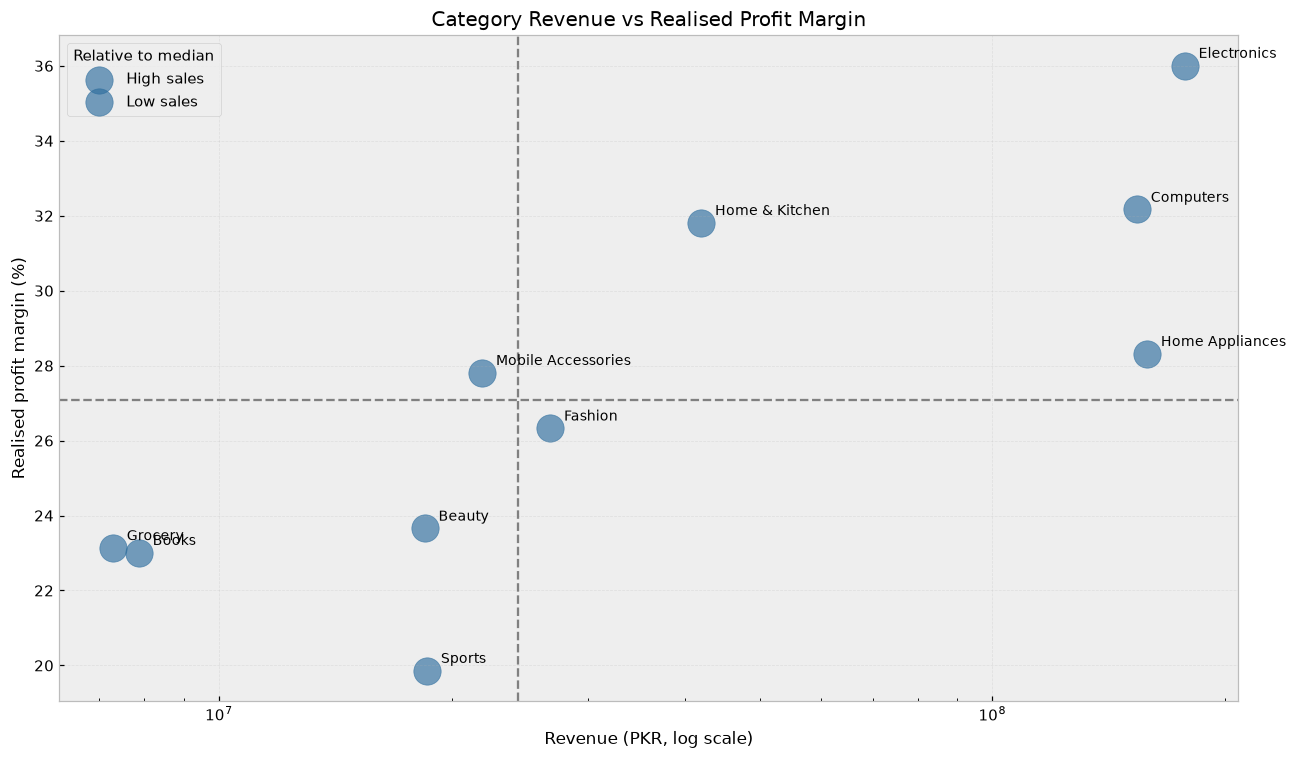

In [52]:
fig, ax = plt.subplots(figsize=(12, 7))
for label, marker, size in [("High sales", "o", 320), ("Low sales", "o", 320)]:
    subset = category_position[category_position["sales_level"] == label]
    ax.scatter(subset["revenue"], subset["realised_margin_percent"],
               s=size, marker=marker, alpha=0.65, label=label, color=PALETTE[0])
ax.axvline(median_revenue, color="grey", linestyle="--", linewidth=1.5)
ax.axhline(median_margin, color="grey", linestyle="--", linewidth=1.5)
for category, row in category_position.iterrows():
    ax.annotate(category, (row["revenue"], row["realised_margin_percent"]),
                textcoords="offset points", xytext=(9, 5), fontsize=9)
ax.set_xscale("log")
money_axis(ax)
ax.set_title("Category Revenue vs Realised Profit Margin")
ax.set_xlabel("Revenue (PKR, log scale)")
ax.set_ylabel("Realised profit margin (%)")
ax.legend(title="Relative to median")
fig.tight_layout()
save_fig(fig, "18_category_revenue_vs_margin")

## Section 14: Summary Visualisation

The charts so far each answered one question. This section combines the
headline results into a single dashboard-style figure so the overall picture
of the business can be seen at a glance. It is a static image, not an
interactive dashboard.

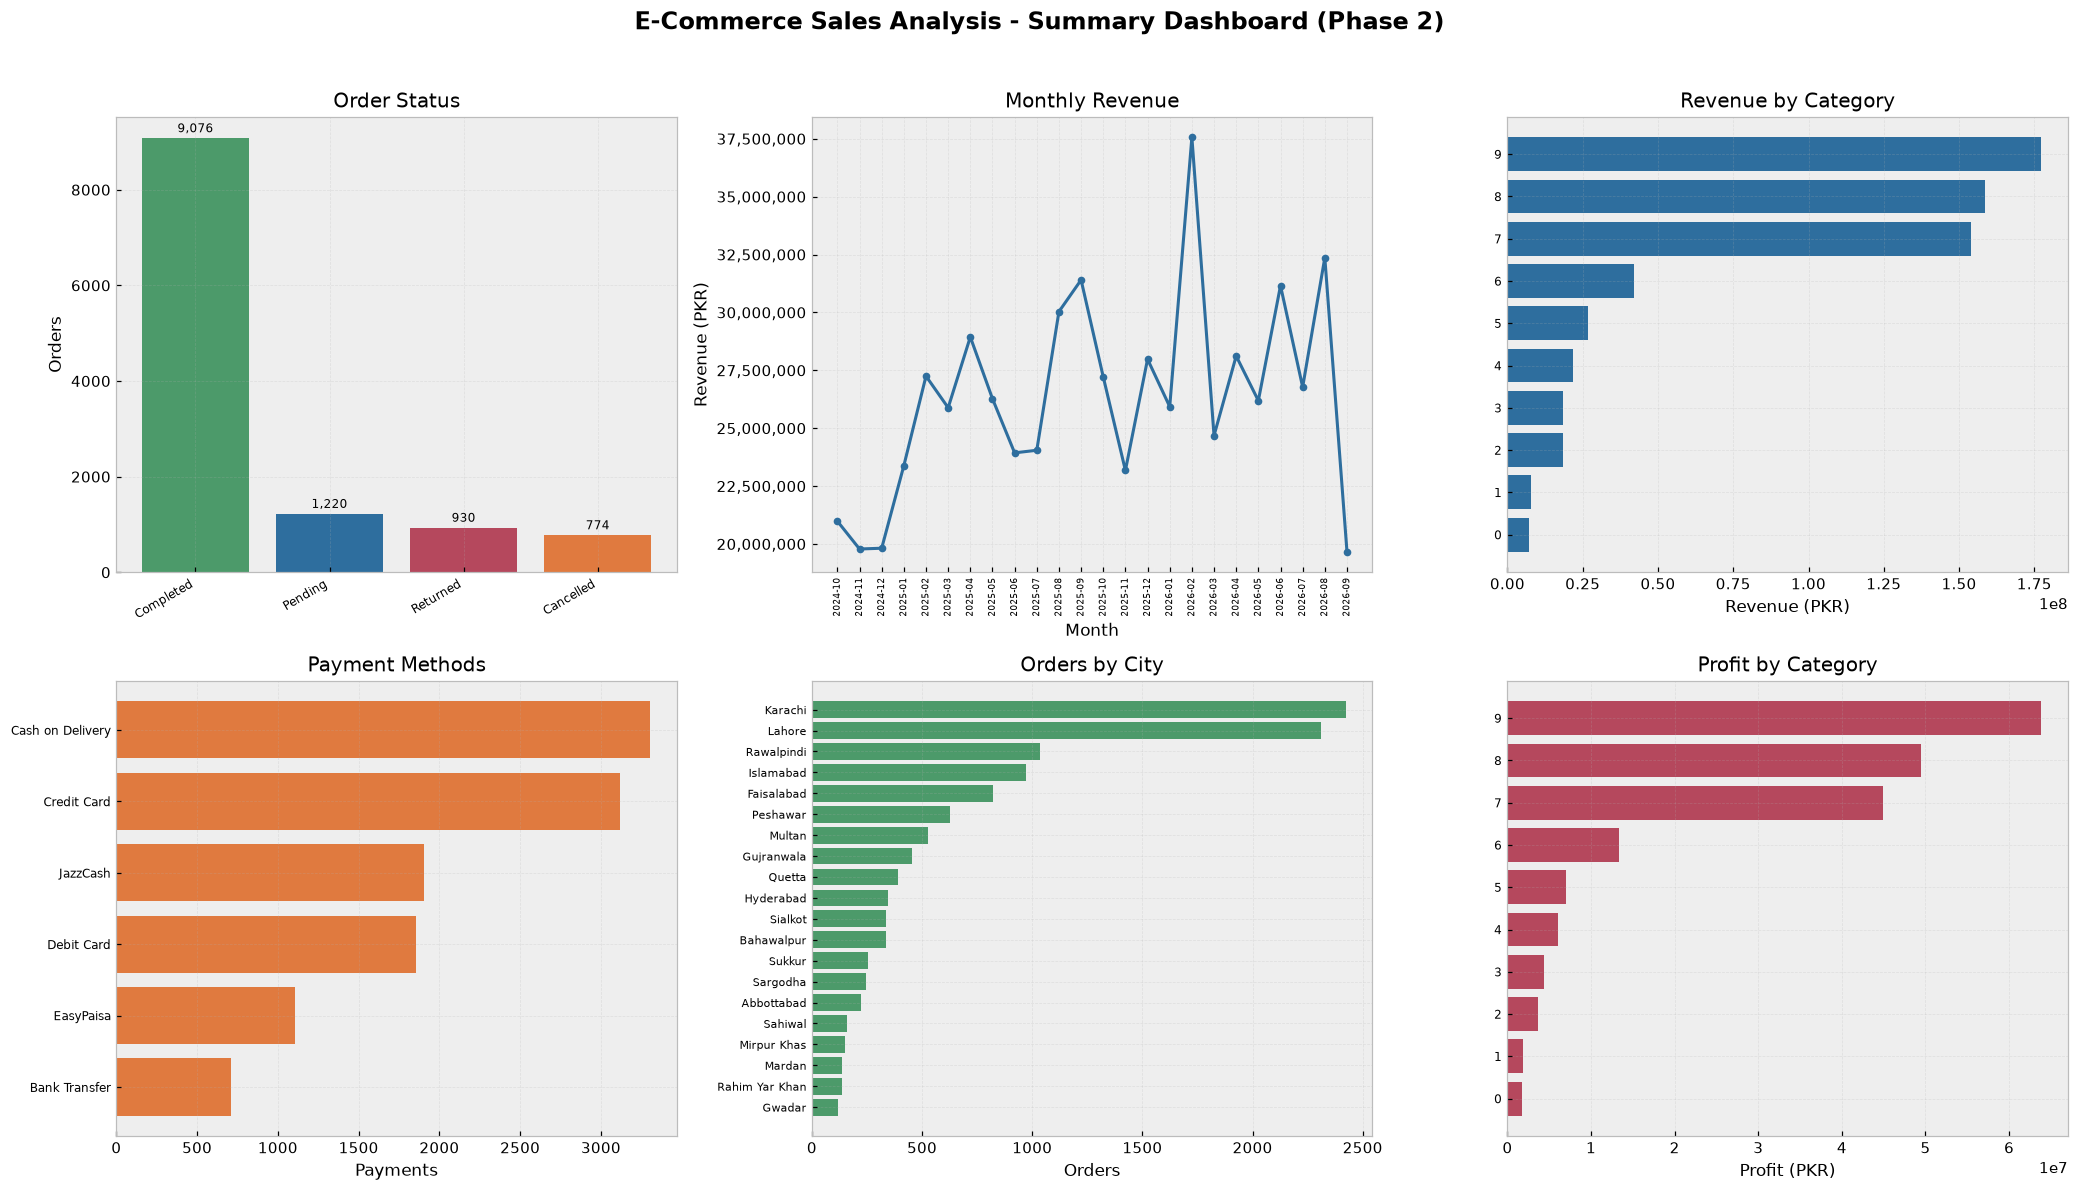

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("E-Commerce Sales Analysis - Summary Dashboard (Phase 2)",
             fontsize=16, fontweight="bold")

# 1 - order status
status_plot = status_counts.sort_values(ascending=False)
axes[0, 0].bar(status_plot.index, status_plot.values,
               color=[PALETTE[2], PALETTE[0], PALETTE[3], PALETTE[1]])
axes[0, 0].set_title("Order Status")
axes[0, 0].set_ylabel("Orders")
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=2, fmt="{:,.0f}", fontsize=8)
plt.setp(axes[0, 0].get_xticklabels(), rotation=30, ha="right", fontsize=8)

# 2 - monthly revenue
axes[0, 1].plot(monthly["order_month"], monthly["revenue"],
                marker="o", markersize=4, linewidth=2, color=PALETTE[0])
axes[0, 1].set_title("Monthly Revenue")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Revenue (PKR)")
money_axis(axes[0, 1])
plt.setp(axes[0, 1].get_xticklabels(), rotation=90, fontsize=6)

# 3 - revenue by category
cat_plot = revenue_by_category.sort_values("revenue")
axes[0, 2].barh(cat_plot.index, cat_plot["revenue"], color=PALETTE[0])
axes[0, 2].set_title("Revenue by Category")
axes[0, 2].set_xlabel("Revenue (PKR)")
money_axis(axes[0, 2])
axes[0, 2].tick_params(axis="y", labelsize=8)

# 4 - payment methods
method_plot = method_counts.sort_values(ascending=False)
axes[1, 0].barh(method_plot.index[::-1], method_plot.values[::-1], color=PALETTE[1])
axes[1, 0].set_title("Payment Methods")
axes[1, 0].set_xlabel("Payments")
axes[1, 0].tick_params(axis="y", labelsize=8)

# 5 - customers by city
city_plot = orders_by_city.sort_values("orders")
axes[1, 1].barh(city_plot.index, city_plot["orders"], color=PALETTE[2])
axes[1, 1].set_title("Orders by City")
axes[1, 1].set_xlabel("Orders")
axes[1, 1].tick_params(axis="y", labelsize=7)

# 6 - profit by category
profit_plot = revenue_by_category.sort_values("profit")
axes[1, 2].barh(profit_plot.index, profit_plot["profit"], color=PALETTE[3])
axes[1, 2].set_title("Profit by Category")
axes[1, 2].set_xlabel("Profit (PKR)")
money_axis(axes[1, 2])
axes[1, 2].tick_params(axis="y", labelsize=8)

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "19_summary_dashboard")

## Section 15: Key Findings

Every statement below is produced from the values calculated in this
notebook. Nothing is written by hand, so the findings cannot drift away from
the data.

In [54]:
findings = []

# Revenue leader
findings.append(
    f"**Revenue is concentrated in a few categories.** {top_category} is the top "
    f"category at PKR {revenue_by_category['revenue'].iloc[0]:,.0f} "
    f"({revenue_by_category['revenue_share'].iloc[0]:.1%} of realised revenue). The top "
    f"3 categories together make up "
    f"{revenue_by_category['revenue_share'].head(3).sum():.1%} of revenue, while the "
    f"bottom 3 make up only {revenue_by_category['revenue_share'].tail(3).sum():.1%}."
)

# City leader
findings.append(
    f"**{best_city} is the most valuable city**, generating PKR "
    f"{revenue_by_city['revenue'].iloc[0]:,.0f} "
    f"({revenue_by_city['revenue_share'].iloc[0]:.1%} of realised revenue) from "
    f"{revenue_by_city['orders'].iloc[0]:,} completed orders. The top 5 cities account "
    f"for {revenue_by_city['revenue_share'].head(5).sum():.1%} of revenue."
)

# Product leaders
overlap_text = ("none of the two lists overlap at all"
                if len(overlap) == 0
                else f"{len(overlap)} of the top 5 products appear on both lists")
findings.append(
    f"**The best-selling product and the highest-revenue product are completely "
    f"different.** '{product_performance.loc[best_units_product, 'product_name']}' "
    f"({product_performance.loc[best_units_product, 'category']}) leads on volume with "
    f"{product_performance.loc[best_units_product, 'units_sold']:,} units, while "
    f"'{product_performance.loc[best_revenue_product, 'product_name']}' "
    f"({product_performance.loc[best_revenue_product, 'category']}) leads on revenue at "
    f"PKR {product_performance.loc[best_revenue_product, 'revenue']:,.0f}, which works out at "
    f"PKR {product_performance.loc[best_revenue_product, 'revenue_per_unit']:,.0f} per unit "
    f"against PKR {product_performance.loc[best_units_product, 'revenue_per_unit']:,.0f} for "
    f"the volume leader. {overlap_text[0].upper()}{overlap_text[1:]}. "
    f"Any 'best seller' report has to state which measure it uses, because the two "
    f"answers name different products."
)

# Seasonality
findings.append(
    f"**Monthly volume is seasonal, not flat.** The busiest month is "
    f"{busiest['order_month']} with {int(busiest['orders']):,} orders, against "
    f"{int(quietest['orders']):,} in the quietest month ({quietest['order_month']}), a "
    f"{busiest['orders'] / quietest['orders']:.2f}x difference. "
    f"Revenue follows the same shape, peaking at PKR {revenue_month['revenue']:,.0f} in "
    f"{revenue_month['order_month']} against PKR {lowest_complete_month['revenue']:,.0f} in "
    f"the weakest complete month."
)

# Growth
findings.append(
    f"**Revenue trends upward, but noisily.** Comparing the first 6 complete months with the "
    f"last 6 complete months, average monthly revenue rises from PKR {first_window_avg:,.0f} "
    f"to PKR {last_window_avg:,.0f}, a gain of {(growth_ratio - 1):+.1%} over the two-year "
    f"window. Individual months swing far more than that, so the trend is only visible over "
    f"several months. The final month ({final_month}) is excluded because the dataset stops "
    f"part way through it, and reading it as a full month would wrongly suggest a collapse "
    f"in sales."
)

# Discounts
findings.append(
    f"**Discounting cost money without buying volume.** A line with 26-30% off earned only "
    f"{revenue_per_line_ratio:.2f}x the revenue per line of an undiscounted line, yet bought "
    f"{units_ratio:.2f}x the quantity - that is, essentially the same quantity. Average "
    f"quantity varies by just {quantity_spread:.2f} units across all seven discount bands. "
    f"PKR {total_discount_given_away:,.0f} was given away on completed orders. On this "
    f"evidence the discount is a margin cost rather than a growth tool."
)

# Margins
findings.append(
    f"**Margin is consistent, and the best seller is also the best margin.** "
    f"{highest_margin_cat} leads on both revenue and realised margin "
    f"({realised_margin['realised_margin_percent'].iloc[0]:.1f}%), so there is no "
    f"high-margin / low-sales trade-off at the top of the catalogue. The whole range across "
    f"all ten categories spans only "
    f"{realised_margin['realised_margin_percent'].iloc[0] - realised_margin['realised_margin_percent'].iloc[-1]:.1f} "
    f"percentage points, from {highest_margin_cat} at "
    f"{realised_margin['realised_margin_percent'].iloc[0]:.1f}% down to {lowest_margin_cat} at "
    f"{realised_margin['realised_margin_percent'].iloc[-1]:.1f}%. Realised margin is below "
    f"catalogue margin everywhere because discounts cut the price but not the cost."
)

# Cancellations and returns
findings.append(
    f"**Failed orders destroy {failed_revenue / gross_revenue:.2%} of gross revenue.** "
    f"{cancellation_rate:.2%} of orders are cancelled and {return_rate:.2%} are returned. "
    f"Failed orders are only {failed_avg / all_avg:.2f}x the size of an average order, so the "
    f"loss tracks the failure count rather than unusually large failed baskets. "
    + (
        f"{worst_loss} is the worst on both counts: it has the highest loss rate at "
        f"{loss_by_category.loc[worst_loss_rate, 'loss_rate_by_category']:.2%} and the largest "
        f"pool of lost money at PKR {loss_by_category['lost_revenue'].iloc[0]:,.0f}."
        if worst_loss == worst_loss_rate else
        f"{worst_loss} is the largest pool of lost money at PKR "
        f"{loss_by_category['lost_revenue'].iloc[0]:,.0f}, while {worst_loss_rate} has the "
        f"worst loss rate at "
        f"{loss_by_category.loc[worst_loss_rate, 'loss_rate_by_category']:.2%}."
    )
)

# Customer behaviour
findings.append(
    f"**Revenue depends on breadth, not on a few big spenders.** {repeat_customer_rate:.1%} of "
    f"active customers order more than once and they produce {repeat_order_share:.1%} of all "
    f"orders, but the top 10 spenders account for only {top10_spend_share:.2%} of revenue. "
    f"Mean spend (PKR {spend_by_customer['revenue'].mean():,.0f}) is only "
    f"{spend_by_customer['revenue'].mean() / median_spend:.1f}x the median (PKR "
    f"{median_spend:,.0f}), so the distribution is right-skewed but not extreme. Separately, "
    f"{inactive_customers} of the {total_customers:,} registered customers "
    f"({inactive_customers / total_customers:.1%}) have never ordered at all."
)

# Payments
findings.append(
    f"**Payment method choice is concentrated and reliability differs.** "
    f"{', '.join(top_methods)} account for "
    f"{method_performance['share'].head(3).sum():.1%} of payments. Failure rates range "
    f"from {method_performance['failure_rate'].min():.2%} ({best_method}) to "
    f"{method_performance['failure_rate'].max():.2%} ({worst_method})."
)

# Data quality
findings.append(
    f"**The data passed every check before analysis.** All "
    f"{len(quality_report)} quality checks passed: no missing values, no duplicate "
    f"primary keys, no orphan foreign keys, and no impossible dates, discounts or "
    f"quantities. The analysis could therefore be trusted without a cleaning step."
)

for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}\n")

1. **Revenue is concentrated in a few categories.** Electronics is the top category at PKR 177,321,319 (28.0% of realised revenue). The top 3 categories together make up 77.4% of revenue, while the bottom 3 make up only 5.3%.

2. **Karachi is the most valuable city**, generating PKR 123,442,174 (19.5% of realised revenue) from 1,859 completed orders. The top 5 cities account for 63.2% of revenue.

3. **The best-selling product and the highest-revenue product are completely different.** 'EBM Peanut Pack' (Grocery) leads on volume with 1,190 units, while 'Polaroid Mirrorless Camera' (Electronics) leads on revenue at PKR 55,289,912, which works out at PKR 341,296 per unit against PKR 726 for the volume leader. None of the two lists overlap at all. Any 'best seller' report has to state which measure it uses, because the two answers name different products.

4. **Monthly volume is seasonal, not flat.** The busiest month is 2026-08 with 669 orders, against 378 in the quietest month (2024-10)

In [55]:
# The same findings as a table, plus the headline metrics and the chart inventory
print("KEY NUMBERS")
print("-" * 92)
for metric, value in headline_metrics.items():
    print(f"  {metric:<36} {value}")

print()
print(f"VISUALISATIONS CREATED ({len(CHART_NAMES)})")
print("-" * 92)
for index, name in enumerate(CHART_NAMES, start=1):
    print(f"  {index:>2}. visualizations/{name}")

KEY NUMBERS
--------------------------------------------------------------------------------------------
  Total orders                         12,000
  Registered customers                 1,500
  Active customers                     1,440
  Inactive customers                   60
  Total products                       300
  Total units sold                     50,694
  Gross revenue (PKR)                  845,400,583
  Realised revenue (PKR)               632,578,306
  Realised profit (PKR)                196,295,406
  Realised profit margin               31.03%
  Average order value (PKR)            69,698
  Average profit per order (PKR)       21,628
  Average units per order              4.22
  Cancellation rate                    6.45%
  Return rate                          7.75%
  Pending rate                         10.17%
  Repeat customer rate                 90.83%

VISUALISATIONS CREATED (19)
----------------------------------------------------------------------------------

## Section 16: Conclusion

### What was done

All five tables from Phase 1 were loaded and checked without modifying a
single CSV file. The data passed every quality check, so no cleaning step
was needed before the analysis could begin.

Each table was explored on its own first, then combined with Pandas merges
into a single `sales` table to answer business questions. Every merge was
verified not to multiply rows, so no total is inflated.

### The central calculation

Revenue was not read from the data, because the dataset deliberately stores
no order total. It was calculated as:

```
revenue = quantity * unit_price * (1 - discount_percent / 100)
```

and profit as `revenue - (quantity * cost)`, using the cost from the product
catalogue. Both were added as in-memory columns only.

### Treatment of order status

Cancelled, returned and pending orders are excluded from revenue, profit and
average order value, because the money was never kept. Gross revenue is also
reported so the difference is visible: the reconciliation table in Section 12
shows exactly how much gross revenue never became a real sale.

### The main pattern in the data

Three things stand out, and each of them is slightly counter-intuitive:

* **Revenue is concentrated** in a few categories and a few cities, but the
concentration is in *absolute* terms, not because margins differ much. The
whole catalogue sits within a narrow margin band, so the revenue ranking is
driven by volume and price, not by profitability.
* **Best seller and best seller by revenue are different products.** Ranking
by units and ranking by money name entirely different items, so a single
"top product" answer is meaningless without saying which measure was used.
* **Discounting did not buy volume.** Revenue per line falls with the size of
the discount while average quantity stays flat, so the discounting in this
period looks like a cost with no measurable return in the data available.

### Next phase

SQL (Phase 3) will answer the same questions against these tables loaded into
MySQL, using JOINs, GROUP BY, subqueries and CASE statements, so the Pandas
results can be used to verify the SQL results.

==== END OF PART 3 ====